IT3091 Machine Learning Group Assignmen

Group: 2026-AI-40


## Notebook Roadmap

1. Business problem framing
2. Project initialization and reproducibility
3. Data loading and data dictionary
4. Data understanding and raw-data quality audit
5. Exploratory data analysis (EDA)
6. EDA insight log and preprocessing handover
7. Customer-level feature engineering
8. Unsupervised clustering models and comparison
9. Cluster evaluation and interpretation
10. Segment-specific market-basket analysis
11. Business recommendations, limitations, and conclusion

1. Business Problem Framing and EDA - IT24100802 Ranawansha P.G.D.D

## 1. Business Problem Framing

### Business Context
The dataset contains transaction-level records from a UK-based online gift retailer. The retailer aims to improve sales, customer retention, and product strategy using historical transaction data.

### Stakeholder
The primary stakeholder is the retailer's marketing and customer relationship management (CRM) team. Secondary stakeholders include merchandising and inventory teams.

### Primary Decision Lens: Customer Segmentation
The primary objective is to identify meaningful and actionable customer groups based on purchasing behaviour. Since the dataset does not contain a predefined customer-level target label, customer segmentation is a suitable unsupervised learning task.

### Secondary Lens: Product Association and Bundling
The secondary objective is to discover product associations within the customer segments identified by the primary analysis. Instead of producing generic rules for every customer, segment-specific market-basket analysis can produce more targeted bundle and cross-selling recommendations.

### Unit of Analysis
- Raw-data stage: One row represents one item within an invoice (invoice-line transaction).
- Customer-segmentation stage: One row will represent one customer after transaction-level data are aggregated.
- Association-rule stage: One transaction will represent one completed invoice/basket.

### Proposed Output
1. Interpretable customer segments using RFM and augmented behavioural features.
2. Comparison of multiple clustering methods.
3. Segment-specific product-association rules using Apriori.
4. Evidence-based marketing, retention, cross-selling, and bundling recommendations.

In [2]:

# 2. Project Initialization and Reproducibility


import os
import sys
import random
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive

warnings.filterwarnings("ignore")

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

# Plot styling
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

print("Python version:", sys.version)
print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)
print("Random seed:", RANDOM_STATE)

Python version: 3.13.16 (main, Oct  1 2026, 15:40:24) [GCC 13.3.0]
Pandas version: 2.2.3
NumPy version: 2.1.3
Random seed: 42


3. Mount Google Drive and Load Data
Code cell

In [3]:


drive.mount('/content/drive')

DATA_PATH = "/content/drive/MyDrive/ML Project/Online Retail.xlsx"

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Dataset not found at:\n{DATA_PATH}\n\n"
        "Please verify that the folder is named 'ML Project' and "
        "the file is named 'Online Retail.xlsx'."
    )

print("Dataset found successfully:")
print(DATA_PATH)

Mounted at /content/drive
Dataset found successfully:
/content/drive/MyDrive/ML Project/Online Retail.xlsx


In [4]:
# Load the Online Retail Excel dataset
df_raw = pd.read_excel(DATA_PATH, engine="openpyxl")

print("Raw dataset loaded successfully.")
print("Raw shape (rows, columns):", df_raw.shape)

display(df_raw.head())

Raw dataset loaded successfully.
Raw shape (rows, columns): (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


Create a copy of dataframe

In [5]:

# Keep df_raw unchanged for auditing and reproducibility.
df = df_raw.copy()

print("Working dataframe created.")

Working dataframe created.


## 4. Dataset Source and Fingerprint

**Dataset:** UCI Machine Learning Repository – Online Retail  
**Source:** https://archive.ics.uci.edu/dataset/352/online+retail  
**File used:** `Online Retail.xlsx`  
**Raw file location:** Google Drive → `MyDrive/ML Project/Online Retail.xlsx`  
**Dataset period:** December 2010 to December 2011  
**Raw unit of analysis:** An invoice-line transaction, where each row records one product in an invoice.

In [6]:
import hashlib

def get_file_hash(file_path, algorithm="sha256"):
    hash_object = hashlib.new(algorithm)
    with open(file_path, "rb") as f:
        for chunk in iter(lambda: f.read(4096), b""):
            hash_object.update(chunk)
    return hash_object.hexdigest()

file_size_mb = os.path.getsize(DATA_PATH) / (1024 * 1024)
file_hash = get_file_hash(DATA_PATH)

print("Dataset file name:", Path(DATA_PATH).name)
print(f"Dataset file size: {file_size_mb:.2f} MB")
print("SHA-256 fingerprint:", file_hash)
print("Load timestamp:", datetime.now().strftime("%Y-%m-%d %H:%M:%S"))

Dataset file name: Online Retail.xlsx
Dataset file size: 22.62 MB
SHA-256 fingerprint: 43465a06f2ccf7c8b5bd2892bc7defb52f97487934fe93b16ae4c3936424676d
Load timestamp: 2026-10-08 05:09:15


5. Data Dictionary

The following table describes the variables in the raw Online Retail dataset and how each will be used in the project.

In [7]:
data_dictionary = pd.DataFrame({
    "Variable": [
        "InvoiceNo",
        "StockCode",
        "Description",
        "Quantity",
        "InvoiceDate",
        "UnitPrice",
        "CustomerID",
        "Country"
    ],
    "Expected Type": [
        "Object / String",
        "Object / String",
        "Object / String",
        "Integer / Numeric",
        "Datetime",
        "Float / Numeric",
        "Float / Identifier",
        "Object / Categorical"
    ],
    "Row-Level Meaning": [
        "Invoice identifier; invoices beginning with 'C' usually indicate cancellations.",
        "Product or item identifier.",
        "Product description.",
        "Number of units purchased or returned.",
        "Date and time of invoice creation.",
        "Price per product unit.",
        "Unique customer identifier.",
        "Country where the customer is located."
    ],
    "Planned Use": [
        "Detect cancellations; aggregate baskets and transactions.",
        "Identify products for item diversity and association rules.",
        "Readable product labels for EDA and association-rule interpretation.",
        "Calculate purchase quantity, returns, and basket statistics.",
        "Calculate recency and temporal purchasing patterns.",
        "Calculate line-level revenue and monetary value.",
        "Aggregate transactions into customer-level segmentation features.",
        "Geographical EDA and potential customer-profile interpretation."
    ]
})

display(data_dictionary)

,Variable,Expected Type,Row-Level Meaning,Planned Use
0,InvoiceNo,Object / String,Invoice identifier; invoices beginning with 'C...,Detect cancellations; aggregate baskets and tr...
1,StockCode,Object / String,Product or item identifier.,Identify products for item diversity and assoc...
2,Description,Object / String,Product description.,Readable product labels for EDA and associatio...
3,Quantity,Integer / Numeric,Number of units purchased or returned.,"Calculate purchase quantity, returns, and bask..."
4,InvoiceDate,Datetime,Date and time of invoice creation.,Calculate recency and temporal purchasing patt...
5,UnitPrice,Float / Numeric,Price per product unit.,Calculate line-level revenue and monetary value.
6,CustomerID,Float / Identifier,Unique customer identifier.,Aggregate transactions into customer-level seg...
7,Country,Object / Categorical,Country where the customer is located.,Geographical EDA and potential customer-profil...


In [8]:
# Compare observed columns against expected project columns
expected_columns = [
    "InvoiceNo", "StockCode", "Description", "Quantity",
    "InvoiceDate", "UnitPrice", "CustomerID", "Country"
]

actual_columns = df_raw.columns.tolist()

print("Actual columns:", actual_columns)
print("\nMissing expected columns:", sorted(set(expected_columns) - set(actual_columns)))
print("Unexpected columns:", sorted(set(actual_columns) - set(expected_columns)))

Actual columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Missing expected columns: []
Unexpected columns: []


6. Basic Data Understanding

In [9]:
print("Dataset shape:", df_raw.shape)

print("\nColumn names:")
print(df_raw.columns.tolist())

print("\nData types:")
display(df_raw.dtypes.to_frame(name="Data Type"))

print("\nFirst five rows:")
display(df_raw.head())

print("\nLast five rows:")
display(df_raw.tail())

print("\nDataset information:")
df_raw.info()

Dataset shape: (541909, 8)

Column names:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Data types:


,Data Type
InvoiceNo,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,datetime64[ns]
UnitPrice,float64
CustomerID,float64
Country,object



First five rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom



Last five rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [10]:
print("Numerical summary:")
display(df_raw.describe().T)

print("Categorical summary:")
display(df_raw.describe(include="object").T)

Numerical summary:


,count,mean,min,25%,50%,75%,max,std
Quantity,541909.0,9.55225,-80995.0,1.0,3.0,10.0,80995.0,218.081158
InvoiceDate,541909,2011-07-04 13:34:57.156386048,2010-12-01 08:26:00,2011-03-28 11:34:00,2011-07-19 17:17:00,2011-10-19 11:27:00,2011-12-09 12:50:00,NaN
UnitPrice,541909.0,4.611114,-11062.06,1.25,2.08,4.13,38970.0,96.759853
CustomerID,406829.0,15287.69057,12346.0,13953.0,15152.0,16791.0,18287.0,1713.600303


Categorical summary:


,count,unique,top,freq
InvoiceNo,541909,25900,573585,1114
StockCode,541909,4070,85123A,2313
Description,540455,4223,WHITE HANGING HEART T-LIGHT HOLDER,2369
Country,541909,38,United Kingdom,495478


The raw dataset is stored at invoice line level rather than customer level. Therefore, direct clustering of raw rows would be inappropriate because multiple rows can belong to the same customer and the same invoice.

For customer segmentation, the data must later be aggregated into a customer-level analytical dataset.

7. Missing-Value Audit

In [11]:
missing_summary = pd.DataFrame({
    "Missing Count": df_raw.isna().sum(),
    "Missing Percentage (%)": (df_raw.isna().mean() * 100).round(2),
    "Non-Missing Count": df_raw.notna().sum(),
    "Data Type": df_raw.dtypes.astype(str)
}).sort_values("Missing Count", ascending=False)

display(missing_summary)

,Missing Count,Missing Percentage (%),Non-Missing Count,Data Type
CustomerID,135080,24.93,406829,float64
Description,1454,0.27,540455,object
StockCode,0,0.00,541909,object
InvoiceNo,0,0.00,541909,object
Quantity,0,0.00,541909,int64
InvoiceDate,0,0.00,541909,datetime64[ns]
UnitPrice,0,0.00,541909,float64
Country,0,0.00,541909,object


In [57]:

# Original Dataset: Variable Types, Missingness, and Cardinality


original_feature_summary = pd.DataFrame({
    "Column": df_raw.columns,
    "Data Type": df_raw.dtypes.astype(str).values,
    "Missing Count": df_raw.isna().sum().values,
    "Missing (%)": (df_raw.isna().mean() * 100).round(2).values,
    "Unique Values": df_raw.nunique(dropna=True).values,
    "Unique (%)": (df_raw.nunique(dropna=True) / len(df_raw) * 100).round(2).values
})

display(original_feature_summary)

,Column,Data Type,Missing Count,Missing (%),Unique Values,Unique (%)
0,InvoiceNo,object,0,0.00,25900,4.78
1,StockCode,object,0,0.00,4070,0.75
2,Description,object,1454,0.27,4223,0.78
3,Quantity,int64,0,0.00,722,0.13
4,InvoiceDate,datetime64[ns],0,0.00,23260,4.29
5,UnitPrice,float64,0,0.00,1630,0.30
6,CustomerID,float64,135080,24.93,4372,0.81
7,Country,object,0,0.00,38,0.01


Numerical Features: Quantity and UnitPrice

In [60]:



numerical_original_features = ["Quantity", "UnitPrice"]

for column in numerical_original_features:
    print(f"\n{'='*70}")
    print(f"Summary statistics for: {column}")
    print(f"{'='*70}")

    display(
        df_raw[column].describe(
            percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
        ).to_frame(name=column)
    )

    print(f"Skewness: {df_raw[column].skew():.2f}")
    print(f"Values <= 0: {(df_raw[column] <= 0).sum():,}")
    print(f"Values > 0: {(df_raw[column] > 0).sum():,}")


Summary statistics for: Quantity


,Quantity
count,541909.000000
mean,9.552250
std,218.081158
min,-80995.000000
1%,-2.000000
5%,1.000000
10%,1.000000
25%,1.000000
50%,3.000000
75%,10.000000


Skewness: -0.26
Values <= 0: 10,624
Values > 0: 531,285

Summary statistics for: UnitPrice


,UnitPrice
count,541909.000000
mean,4.611114
std,96.759853
min,-11062.060000
1%,0.190000
5%,0.420000
10%,0.630000
25%,1.250000
50%,2.080000
75%,4.130000


Skewness: 186.51
Values <= 0: 2,517
Values > 0: 539,392


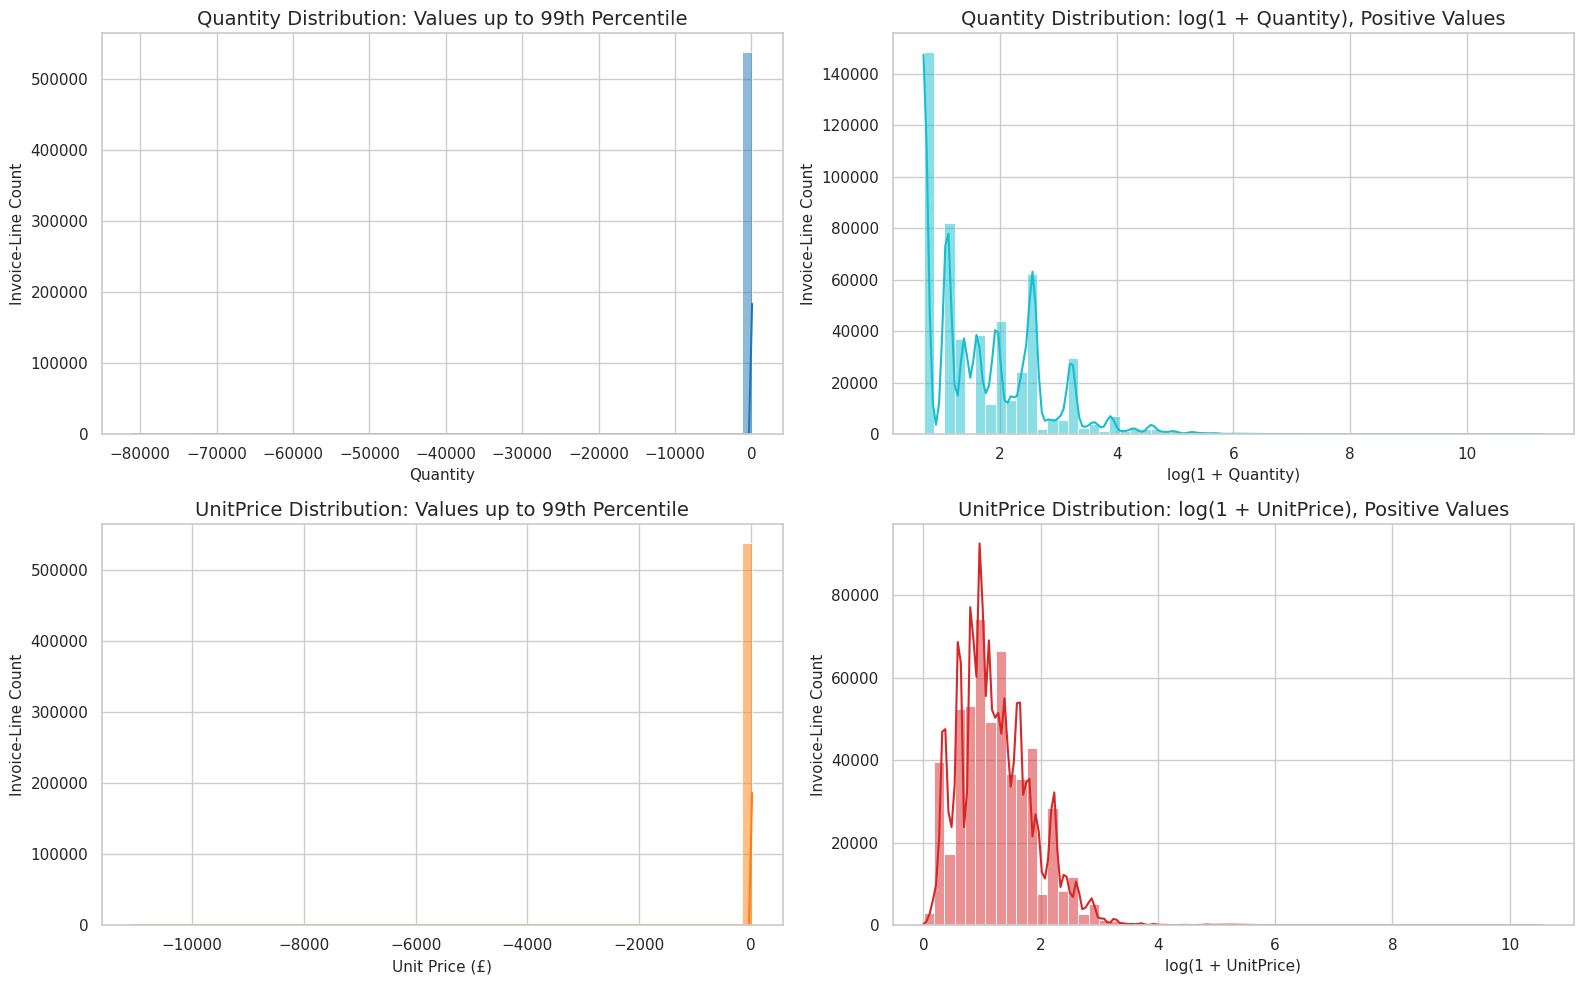

In [61]:
# Histograms and boxplots for original numeric variables
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Quantity: raw histogram restricted to central 99% for visibility
quantity_99 = df_raw["Quantity"].quantile(0.99)

sns.histplot(
    data=df_raw[df_raw["Quantity"] <= quantity_99],
    x="Quantity",
    bins=60,
    kde=True,
    ax=axes[0, 0],
    color="#1f77b4"
)
axes[0, 0].set_title("Quantity Distribution: Values up to 99th Percentile")
axes[0, 0].set_xlabel("Quantity")
axes[0, 0].set_ylabel("Invoice-Line Count")

# Quantity: log scale, only positive values
sns.histplot(
    np.log1p(df_raw.loc[df_raw["Quantity"] > 0, "Quantity"]),
    bins=60,
    kde=True,
    ax=axes[0, 1],
    color="#17becf"
)
axes[0, 1].set_title("Quantity Distribution: log(1 + Quantity), Positive Values")
axes[0, 1].set_xlabel("log(1 + Quantity)")
axes[0, 1].set_ylabel("Invoice-Line Count")

# UnitPrice: raw histogram restricted to central 99% for visibility
unitprice_99 = df_raw["UnitPrice"].quantile(0.99)

sns.histplot(
    data=df_raw[df_raw["UnitPrice"] <= unitprice_99],
    x="UnitPrice",
    bins=60,
    kde=True,
    ax=axes[1, 0],
    color="#ff7f0e"
)
axes[1, 0].set_title("UnitPrice Distribution: Values up to 99th Percentile")
axes[1, 0].set_xlabel("Unit Price (£)")
axes[1, 0].set_ylabel("Invoice-Line Count")

# UnitPrice: log scale, only positive values
sns.histplot(
    np.log1p(df_raw.loc[df_raw["UnitPrice"] > 0, "UnitPrice"]),
    bins=60,
    kde=True,
    ax=axes[1, 1],
    color="#d62728"
)
axes[1, 1].set_title("UnitPrice Distribution: log(1 + UnitPrice), Positive Values")
axes[1, 1].set_xlabel("log(1 + UnitPrice)")
axes[1, 1].set_ylabel("Invoice-Line Count")

plt.tight_layout()
plt.show()

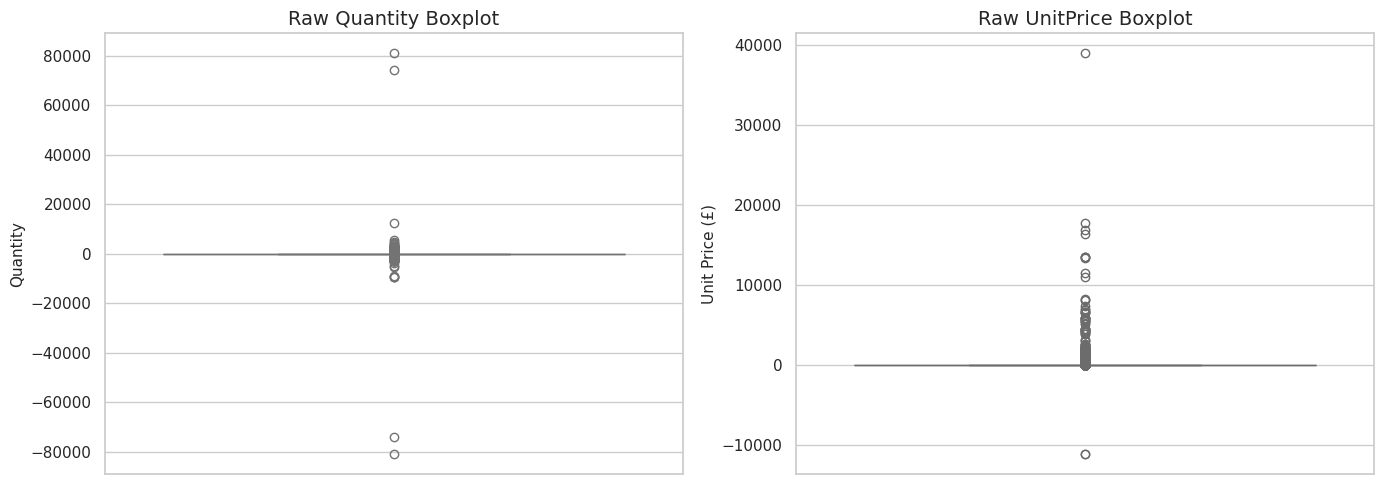

In [62]:
# Raw numeric boxplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(y=df_raw["Quantity"], ax=axes[0], color="#9ecae1")
axes[0].set_title("Raw Quantity Boxplot")
axes[0].set_ylabel("Quantity")

sns.boxplot(y=df_raw["UnitPrice"], ax=axes[1], color="#fdae6b")
axes[1].set_title("Raw UnitPrice Boxplot")
axes[1].set_ylabel("Unit Price (£)")

plt.tight_layout()
plt.show()

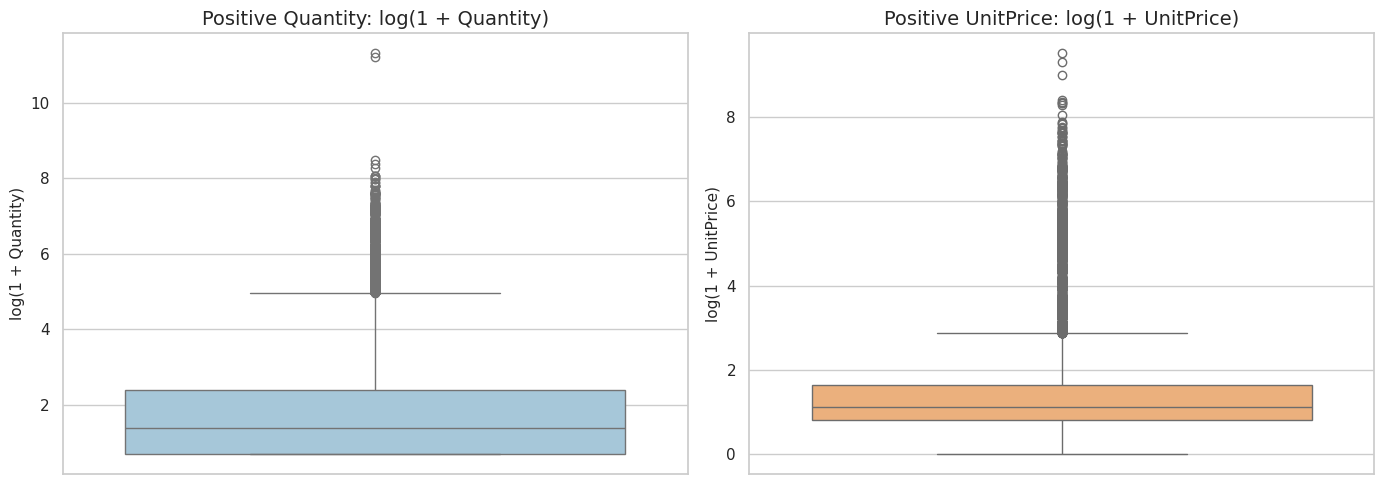

In [63]:
# Log-transformed boxplots for readable outlier/skewness inspection
positive_numeric = df_raw.loc[
    (df_raw["Quantity"] > 0) & (df_raw["UnitPrice"] > 0),
    ["Quantity", "UnitPrice"]
].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(y=np.log1p(positive_numeric["Quantity"]), ax=axes[0], color="#9ecae1")
axes[0].set_title("Positive Quantity: log(1 + Quantity)")
axes[0].set_ylabel("log(1 + Quantity)")

sns.boxplot(y=np.log1p(positive_numeric["UnitPrice"]), ax=axes[1], color="#fdae6b")
axes[1].set_title("Positive UnitPrice: log(1 + UnitPrice)")
axes[1].set_ylabel("log(1 + UnitPrice)")

plt.tight_layout()
plt.show()

 InvoiceNo Distribution

In [64]:

# InvoiceNo Distribution: Invoice-Line Counts and Cancellations

invoice_raw_eda = df_raw.copy()

invoice_raw_eda["InvoiceNo_str"] = (
    invoice_raw_eda["InvoiceNo"]
    .astype(str)
    .str.strip()
)

invoice_raw_eda["IsCancellation"] = invoice_raw_eda["InvoiceNo_str"].str.startswith("C")

invoice_line_counts = (
    invoice_raw_eda
    .groupby(["InvoiceNo_str", "IsCancellation"], as_index=False)
    .size()
    .rename(columns={"size": "ItemsPerInvoice"})
)

display(invoice_line_counts.head())

,InvoiceNo_str,IsCancellation,ItemsPerInvoice
0,536365,False,7
1,536366,False,2
2,536367,False,12
3,536368,False,4
4,536369,False,1


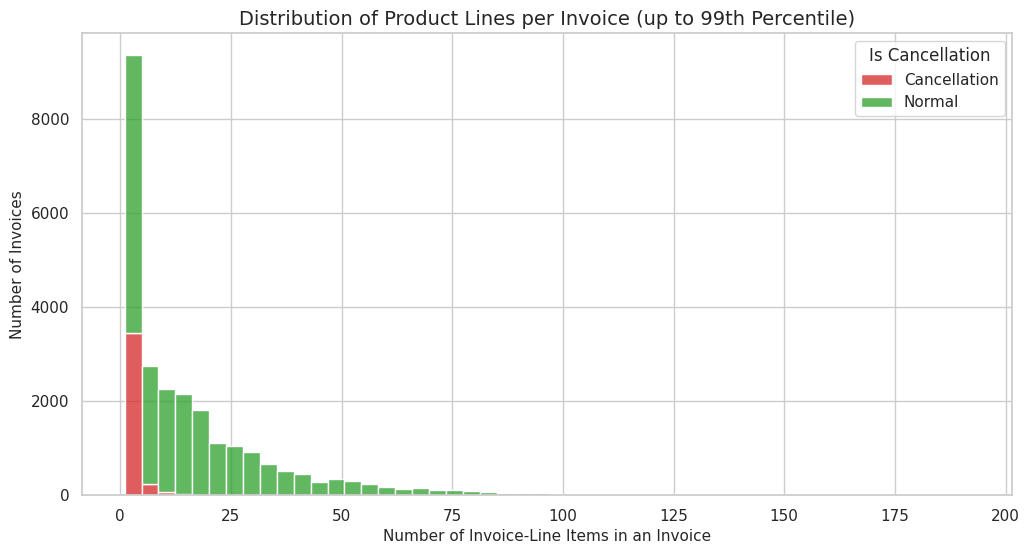

In [65]:
# Distribution of number of invoice-line items per invoice
invoice_items_99 = invoice_line_counts["ItemsPerInvoice"].quantile(0.99)

plt.figure(figsize=(12, 6))
sns.histplot(
    data=invoice_line_counts[
        invoice_line_counts["ItemsPerInvoice"] <= invoice_items_99
    ],
    x="ItemsPerInvoice",
    hue="IsCancellation",
    bins=50,
    multiple="stack",
    palette={False: "#2ca02c", True: "#d62728"}
)

plt.title("Distribution of Product Lines per Invoice (up to 99th Percentile)")
plt.xlabel("Number of Invoice-Line Items in an Invoice")
plt.ylabel("Number of Invoices")
plt.legend(title="Is Cancellation", labels=["Cancellation", "Normal"])
plt.show()

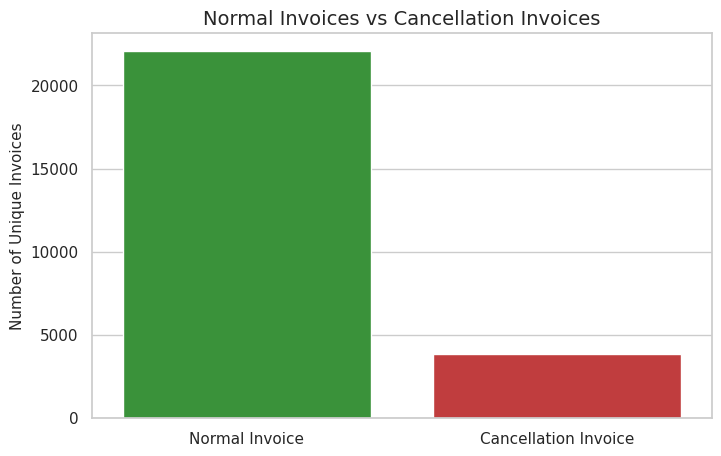

In [66]:
# Normal vs cancellation invoice distribution
invoice_type_summary = (
    invoice_line_counts["IsCancellation"]
    .map({False: "Normal Invoice", True: "Cancellation Invoice"})
    .value_counts()
    .reset_index()
)

invoice_type_summary.columns = ["Invoice Type", "Number of Invoices"]

plt.figure(figsize=(8, 5))
sns.barplot(
    data=invoice_type_summary,
    x="Invoice Type",
    y="Number of Invoices",
    palette=["#2ca02c", "#d62728"]
)

plt.title("Normal Invoices vs Cancellation Invoices")
plt.xlabel("")
plt.ylabel("Number of Unique Invoices")
plt.show()

 StockCode Distribution

In [67]:


stockcode_frequency = (
    df_raw["StockCode"]
    .astype(str)
    .str.strip()
    .value_counts()
    .reset_index()
)

stockcode_frequency.columns = ["StockCode", "InvoiceLineCount"]

display(stockcode_frequency.head(20))

,StockCode,InvoiceLineCount
0,85123A,2313
1,22423,2203
2,85099B,2159
3,47566,1727
4,20725,1639
5,84879,1502
6,22720,1477
7,22197,1476
8,21212,1385
9,20727,1350


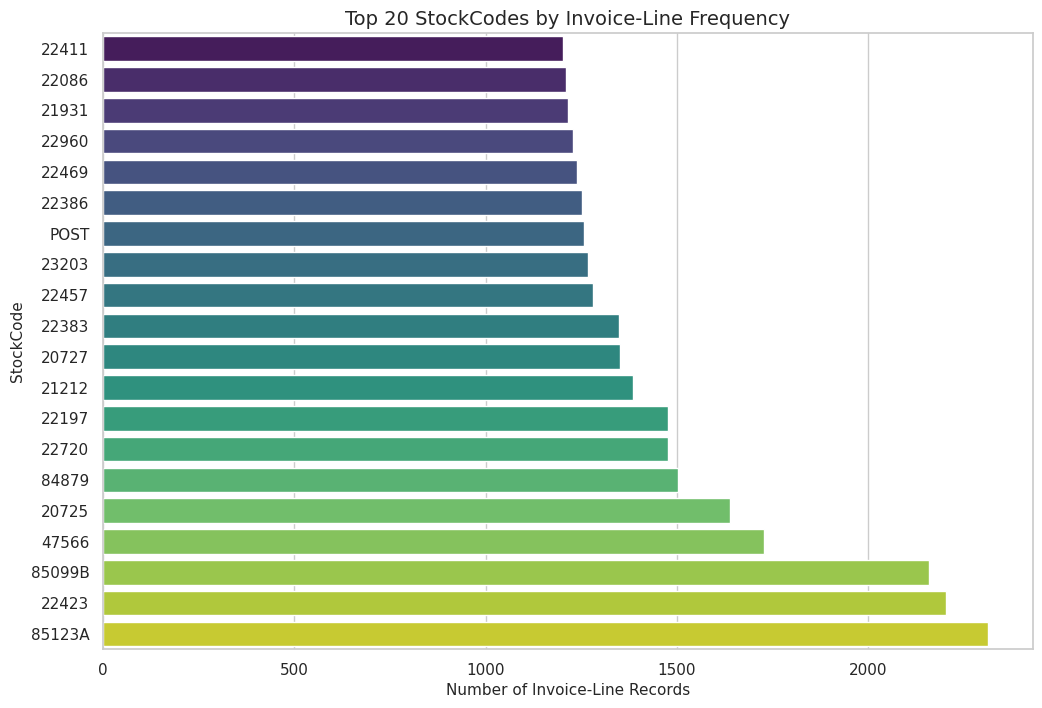

In [68]:
# Top 20 StockCodes by number of invoice-line appearances
top_stockcodes = stockcode_frequency.head(20)

plt.figure(figsize=(12, 8))
sns.barplot(
    data=top_stockcodes.sort_values("InvoiceLineCount"),
    x="InvoiceLineCount",
    y="StockCode",
    palette="viridis"
)

plt.title("Top 20 StockCodes by Invoice-Line Frequency")
plt.xlabel("Number of Invoice-Line Records")
plt.ylabel("StockCode")
plt.show()

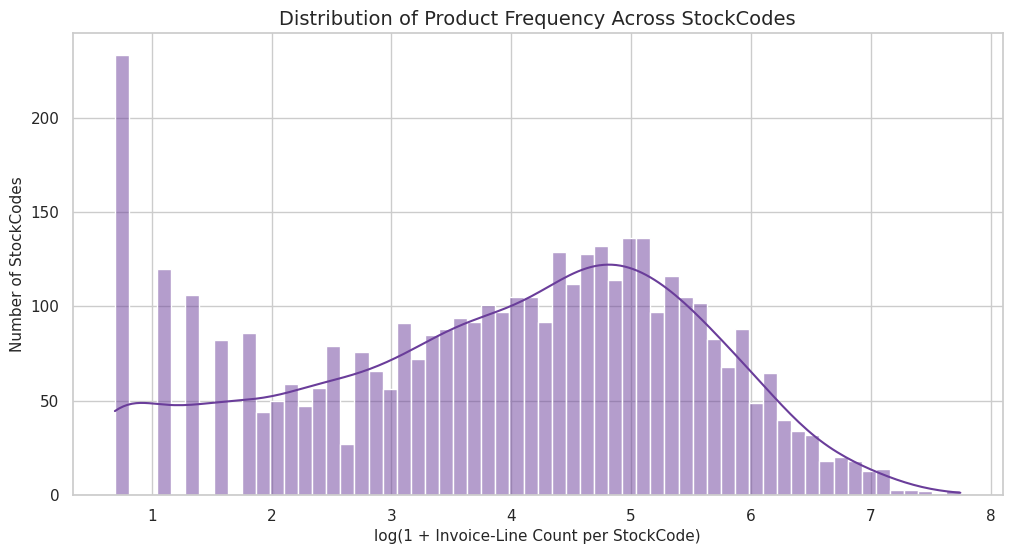

In [69]:
# Product frequency long-tail distribution
plt.figure(figsize=(12, 6))

sns.histplot(
    np.log1p(stockcode_frequency["InvoiceLineCount"]),
    bins=60,
    kde=True,
    color="#6a3d9a"
)

plt.title("Distribution of Product Frequency Across StockCodes")
plt.xlabel("log(1 + Invoice-Line Count per StockCode)")
plt.ylabel("Number of StockCodes")
plt.show()

InvoiceDate Distribution

In [70]:

date_eda = df_raw.copy()
date_eda["InvoiceDate"] = pd.to_datetime(date_eda["InvoiceDate"], errors="coerce")

date_eda["InvoiceMonth"] = date_eda["InvoiceDate"].dt.to_period("M").astype(str)
date_eda["DayOfWeek"] = date_eda["InvoiceDate"].dt.day_name()
date_eda["Hour"] = date_eda["InvoiceDate"].dt.hour

monthly_raw_counts = (
    date_eda
    .groupby("InvoiceMonth", as_index=False)
    .size()
    .rename(columns={"size": "InvoiceLineCount"})
)

display(monthly_raw_counts)

,InvoiceMonth,InvoiceLineCount
0,2010-12,42481
1,2011-01,35147
2,2011-02,27707
3,2011-03,36748
4,2011-04,29916
5,2011-05,37030
6,2011-06,36874
7,2011-07,39518
8,2011-08,35284
9,2011-09,50226


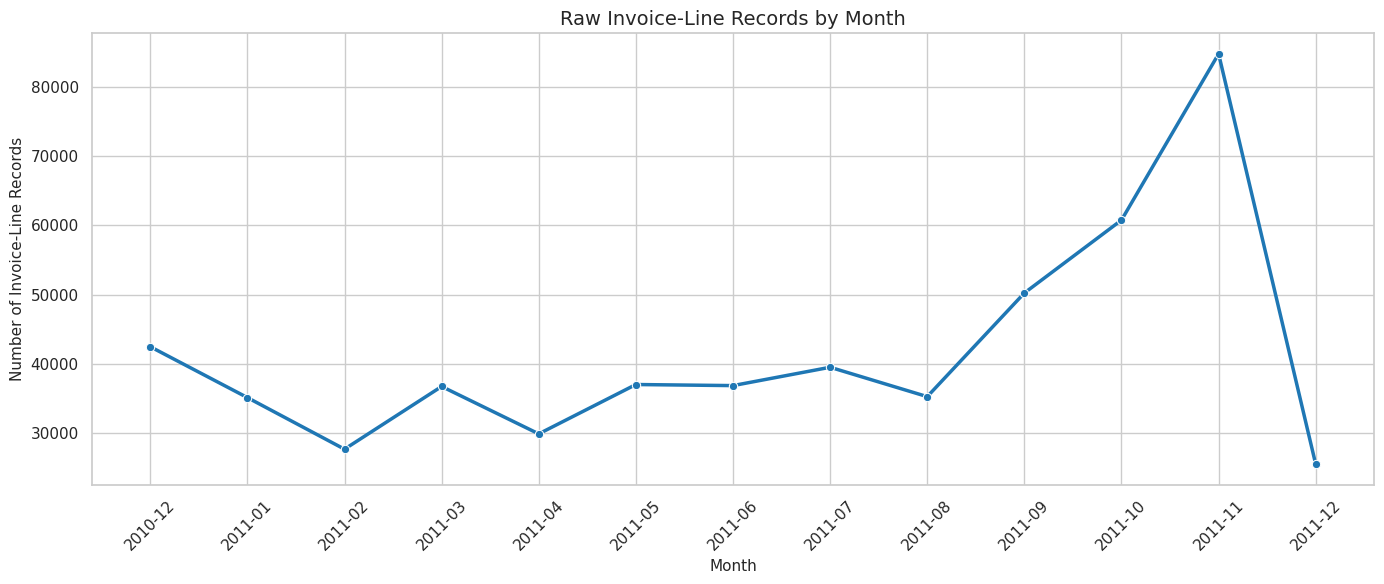

In [71]:
# Monthly raw invoice-line distribution
plt.figure(figsize=(14, 6))
sns.lineplot(
    data=monthly_raw_counts,
    x="InvoiceMonth",
    y="InvoiceLineCount",
    marker="o",
    linewidth=2.5,
    color="#1f77b4"
)

plt.title("Raw Invoice-Line Records by Month")
plt.xlabel("Month")
plt.ylabel("Number of Invoice-Line Records")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

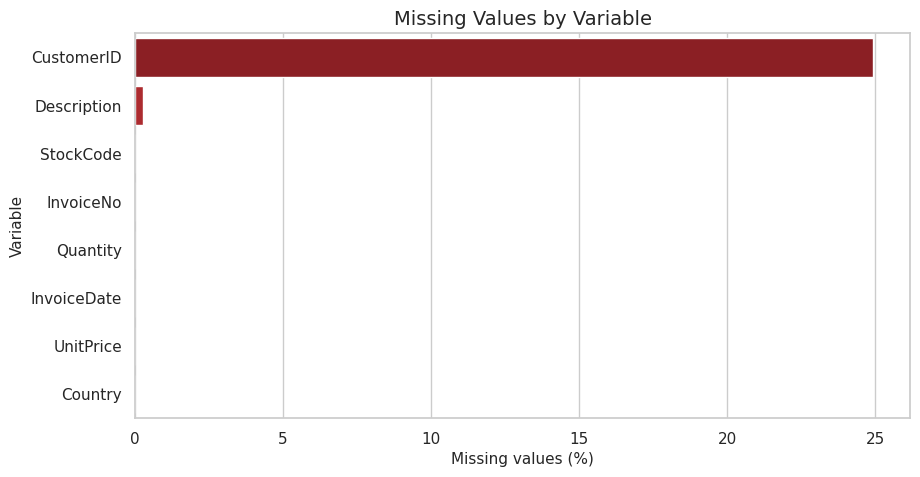

In [12]:
# Visualize missingness by variable
missing_plot = missing_summary.reset_index().rename(columns={"index": "Column"})

plt.figure(figsize=(10, 5))
sns.barplot(
    data=missing_plot,
    x="Missing Percentage (%)",
    y="Column",
    palette="Reds_r"
)
plt.title("Missing Values by Variable")
plt.xlabel("Missing values (%)")
plt.ylabel("Variable")
plt.show()

In [13]:
# Examine rows with missing CustomerID
missing_customer_rows = df_raw[df_raw["CustomerID"].isna()].copy()

print("Rows with missing CustomerID:", len(missing_customer_rows))
print("Percentage of all raw rows:",
      round(len(missing_customer_rows) / len(df_raw) * 100, 2), "%")

display(missing_customer_rows.head(10))

Rows with missing CustomerID: 135080
Percentage of all raw rows: 24.93 %


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.00,NaN,United Kingdom
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1445,536544,21786,POLKADOT RAIN HAT,4,2010-12-01 14:32:00,0.85,NaN,United Kingdom
1446,536544,21787,RAIN PONCHO RETROSPOT,2,2010-12-01 14:32:00,1.66,NaN,United Kingdom
1447,536544,21790,VINTAGE SNAP CARDS,9,2010-12-01 14:32:00,1.66,NaN,United Kingdom
1448,536544,21791,VINTAGE HEADS AND TAILS CARD GAME,2,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1449,536544,21801,CHRISTMAS TREE DECORATION WITH BELL,10,2010-12-01 14:32:00,0.43,NaN,United Kingdom
1450,536544,21802,CHRISTMAS TREE HEART DECORATION,9,2010-12-01 14:32:00,0.43,NaN,United Kingdom
1451,536544,21803,CHRISTMAS TREE STAR DECORATION,11,2010-12-01 14:32:00,0.43,NaN,United Kingdom


In [15]:
# Revenue proxy for rows that have enough information to calculate it
df_missing_revenue = df_raw.copy()
df_missing_revenue["LineRevenue"] = (
    df_missing_revenue["Quantity"] * df_missing_revenue["UnitPrice"]
)

total_observed_revenue = df_missing_revenue.loc[
    df_missing_revenue["LineRevenue"] > 0, "LineRevenue"
].sum()

missing_id_positive_revenue = df_missing_revenue.loc[
    (df_missing_revenue["CustomerID"].isna()) &
    (df_missing_revenue["LineRevenue"] > 0),
    "LineRevenue"
].sum()

print(f"Total positive observed revenue: £{total_observed_revenue:,.2f}")
print(f"Positive revenue linked to missing CustomerID: £{missing_id_positive_revenue:,.2f}")
print(
    "Revenue share affected by missing CustomerID:",
    f"{(missing_id_positive_revenue / total_observed_revenue * 100):.2f}%"
)

Total positive observed revenue: £10,666,684.54
Positive revenue linked to missing CustomerID: £1,755,276.64
Revenue share affected by missing CustomerID: 16.46%


CustomerID is essential for customer-level segmentation because it links multiple transactions to the same customer. Transactions with a missing CustomerID cannot be assigned to a customer segment and cannot be used to calculate customer level Recency, Frequency, Monetary value, return rate, or item diversity.

Therefore, the preprocessing stage should quantify the row and revenue impact of missing CustomerIDs and remove those records from the customer-segmentation dataset. This removal should be documented as an analytical necessity, rather than treating CustomerID as a value that can be imputed.


8.Duplicate audit

In [16]:
exact_duplicate_count = df_raw.duplicated().sum()
exact_duplicate_percentage = exact_duplicate_count / len(df_raw) * 100

print("Exact duplicate rows:", exact_duplicate_count)
print(f"Exact duplicate percentage: {exact_duplicate_percentage:.4f}%")

if exact_duplicate_count > 0:
    print("\nExample duplicate rows:")
    display(df_raw[df_raw.duplicated(keep=False)].sort_values(df_raw.columns.tolist()).head(20))

Exact duplicate rows: 5268
Exact duplicate percentage: 0.9721%

Example duplicate rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
578,536412,21448,12 DAISY PEGS IN WOOD BOX,1,2010-12-01 11:49:00,1.65,17920.0,United Kingdom
598,536412,21448,12 DAISY PEGS IN WOOD BOX,1,2010-12-01 11:49:00,1.65,17920.0,United Kingdom


In [17]:
# Potential duplicate invoice-line records
invoice_line_columns = [
    "InvoiceNo", "StockCode", "Description",
    "Quantity", "InvoiceDate", "UnitPrice",
    "CustomerID", "Country"
]

potential_duplicate_count = df_raw.duplicated(subset=invoice_line_columns).sum()

print("Potential duplicate invoice-line records:", potential_duplicate_count)

Potential duplicate invoice-line records: 5268


Exact duplicate rows may represent accidental duplicate data records, but they should not be removed automatically without checking their business meaning. In retail transaction data, repeated products in the same invoice can be valid when the same product appears as separate invoice lines.

9. Invoice and Cancellation Audit

In [18]:

# Preserve InvoiceNo as string to safely detect cancellation invoices.
invoice_as_string = df_raw["InvoiceNo"].astype(str).str.strip()

df_invoice_audit = df_raw.copy()
df_invoice_audit["InvoiceNo_str"] = invoice_as_string
df_invoice_audit["IsCancellation"] = df_invoice_audit["InvoiceNo_str"].str.startswith("C", na=False)

cancellation_summary = pd.DataFrame({
    "Metric": [
        "Total invoice-line rows",
        "Cancellation invoice-line rows",
        "Non-cancellation invoice-line rows",
        "Cancellation row percentage",
        "Unique cancellation invoices",
        "Unique non-cancellation invoices"
    ],
    "Value": [
        len(df_invoice_audit),
        df_invoice_audit["IsCancellation"].sum(),
        (~df_invoice_audit["IsCancellation"]).sum(),
        round(df_invoice_audit["IsCancellation"].mean() * 100, 2),
        df_invoice_audit.loc[df_invoice_audit["IsCancellation"], "InvoiceNo"].nunique(),
        df_invoice_audit.loc[~df_invoice_audit["IsCancellation"], "InvoiceNo"].nunique()
    ]
})

display(cancellation_summary)

,Metric,Value
0,Total invoice-line rows,541909.00
1,Cancellation invoice-line rows,9288.00
2,Non-cancellation invoice-line rows,532621.00
3,Cancellation row percentage,1.71
4,Unique cancellation invoices,3836.00
5,Unique non-cancellation invoices,22064.00


In [19]:
# Compare quantity and line revenue patterns for cancellation vs non-cancellation records
df_invoice_audit["LineRevenue"] = (
    df_invoice_audit["Quantity"] * df_invoice_audit["UnitPrice"]
)

cancellation_comparison = df_invoice_audit.groupby("IsCancellation").agg(
    Rows=("InvoiceNo", "size"),
    UniqueInvoices=("InvoiceNo", "nunique"),
    MeanQuantity=("Quantity", "mean"),
    MedianQuantity=("Quantity", "median"),
    NegativeQuantityRate=("Quantity", lambda x: (x < 0).mean() * 100),
    MeanLineRevenue=("LineRevenue", "mean"),
    TotalLineRevenue=("LineRevenue", "sum")
).round(2)

cancellation_comparison.index = cancellation_comparison.index.map({
    False: "Normal / Non-cancellation",
    True: "Cancellation"
})

display(cancellation_comparison)

,Rows,UniqueInvoices,MeanQuantity,MedianQuantity,NegativeQuantityRate,MeanLineRevenue,TotalLineRevenue
IsCancellation,,,,,,,
Normal / Non-cancellation,532621,22064,10.24,3.0,0.25,19.99,10644560.42
Cancellation,9288,3836,-29.89,-2.0,100.00,-96.56,-896812.49


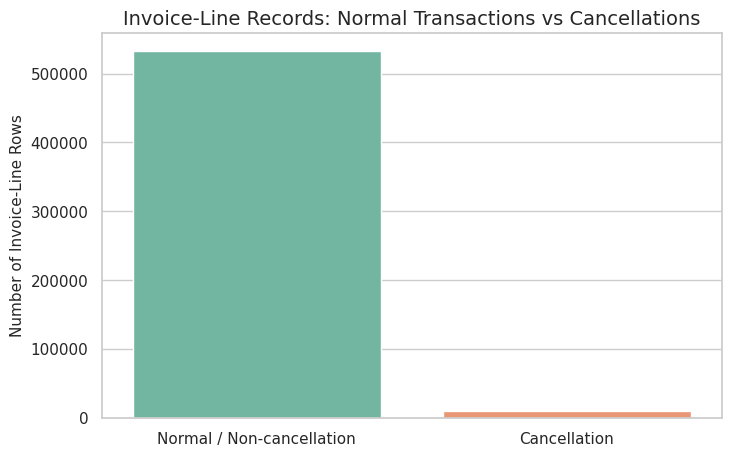

In [20]:
# Visualize cancellation vs non-cancellation row count
plot_data = (
    df_invoice_audit["IsCancellation"]
    .map({False: "Normal / Non-cancellation", True: "Cancellation"})
    .value_counts()
    .reset_index()
)

plot_data.columns = ["Transaction Type", "Row Count"]

plt.figure(figsize=(8, 5))
sns.barplot(data=plot_data, x="Transaction Type", y="Row Count", palette="Set2")
plt.title("Invoice-Line Records: Normal Transactions vs Cancellations")
plt.xlabel("")
plt.ylabel("Number of Invoice-Line Rows")
plt.show()

Invoices starting with `C` indicate cancelled transactions. These records commonly have negative quantities and negative line revenue, which represent returned or reversed purchases rather than completed customer demand.

For the primary customer-segmentation and market-basket objectives, the preprocessing pipeline should create a completed-purchase dataset by excluding cancellation invoices and retaining only valid positive purchases. However, cancellation behaviour should not simply be ignored: it will first be analysed and can later support a return-related feature such as return rate.

10. Invalid Quantity and Price Audit

In [21]:


quantity_price_audit = pd.DataFrame({
    "Condition": [
        "Quantity <= 0",
        "Quantity = 0",
        "Quantity < 0",
        "UnitPrice <= 0",
        "UnitPrice = 0",
        "UnitPrice < 0",
        "Positive Quantity and Positive UnitPrice"
    ],
    "Row Count": [
        (df_raw["Quantity"] <= 0).sum(),
        (df_raw["Quantity"] == 0).sum(),
        (df_raw["Quantity"] < 0).sum(),
        (df_raw["UnitPrice"] <= 0).sum(),
        (df_raw["UnitPrice"] == 0).sum(),
        (df_raw["UnitPrice"] < 0).sum(),
        ((df_raw["Quantity"] > 0) & (df_raw["UnitPrice"] > 0)).sum()
    ]
})

quantity_price_audit["Percentage of Rows (%)"] = (
    quantity_price_audit["Row Count"] / len(df_raw) * 100
).round(2)

display(quantity_price_audit)

,Condition,Row Count,Percentage of Rows (%)
0,Quantity <= 0,10624,1.96
1,Quantity = 0,0,0.00
2,Quantity < 0,10624,1.96
3,UnitPrice <= 0,2517,0.46
4,UnitPrice = 0,2515,0.46
5,UnitPrice < 0,2,0.00
6,Positive Quantity and Positive UnitPrice,530104,97.82


In [22]:
# Summary of quantity and price
numeric_raw_summary = df_raw[["Quantity", "UnitPrice"]].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
).T

display(numeric_raw_summary)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
Quantity,541909.0,9.552250,218.081158,-80995.00,-2.00,1.00,1.00,3.00,10.00,29.00,100.0,80995.0
UnitPrice,541909.0,4.611114,96.759853,-11062.06,0.19,0.42,1.25,2.08,4.13,9.95,18.0,38970.0


In [23]:

print("Highest Quantity rows:")
display(
    df_raw.nlargest(10, "Quantity")[
        ["InvoiceNo", "StockCode", "Description", "Quantity",
         "UnitPrice", "CustomerID", "Country"]
    ]
)

print("Highest UnitPrice rows:")
display(
    df_raw.nlargest(10, "UnitPrice")[
        ["InvoiceNo", "StockCode", "Description", "Quantity",
         "UnitPrice", "CustomerID", "Country"]
    ]
)

Highest Quantity rows:


,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Country
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,16446.0,United Kingdom
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04,12346.0,United Kingdom
502122,578841,84826,ASSTD DESIGN 3D PAPER STICKERS,12540,0.00,13256.0,United Kingdom
74614,542504,37413,NaN,5568,0.00,NaN,United Kingdom
421632,573008,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,4800,0.21,12901.0,United Kingdom
206121,554868,22197,SMALL POPCORN HOLDER,4300,0.72,13135.0,United Kingdom
220843,556231,85123A,?,4000,0.00,NaN,United Kingdom
97432,544612,22053,EMPIRE DESIGN ROSETTE,3906,0.82,18087.0,United Kingdom
270885,560599,18007,ESSENTIAL BALM 3.5g TIN IN ENVELOPE,3186,0.06,14609.0,United Kingdom
52711,540815,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,15749.0,United Kingdom


Highest UnitPrice rows:


,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Country
222681,C556445,M,Manual,-1,38970.00,15098.0,United Kingdom
524602,C580605,AMAZONFEE,AMAZON FEE,-1,17836.46,NaN,United Kingdom
43702,C540117,AMAZONFEE,AMAZON FEE,-1,16888.02,NaN,United Kingdom
43703,C540118,AMAZONFEE,AMAZON FEE,-1,16453.71,NaN,United Kingdom
15016,C537630,AMAZONFEE,AMAZON FEE,-1,13541.33,NaN,United Kingdom
15017,537632,AMAZONFEE,AMAZON FEE,1,13541.33,NaN,United Kingdom
16356,C537651,AMAZONFEE,AMAZON FEE,-1,13541.33,NaN,United Kingdom
16232,C537644,AMAZONFEE,AMAZON FEE,-1,13474.79,NaN,United Kingdom
524601,C580604,AMAZONFEE,AMAZON FEE,-1,11586.50,NaN,United Kingdom
299982,A563185,B,Adjust bad debt,1,11062.06,NaN,United Kingdom


Quantity and UnitPrice values are required to calculate transaction revenue


LineRevenue = Quantity x UnitPrice


Rows with non-positive quantity or non-positive unit price do not represent normal completed sales. The preprocessing stage should define a completed-purchase subset by retaining rows where Quantity > 0 and UnitPrice > 0, after separately identifying cancellation-related rows.

Extreme but valid positive values should be investigated instead of automatically removed. In a wholesale retail setting, large orders may represent genuine high-value customers rather than data-entry errors.

11. Create EDA Only Derived Variables

In [24]:

df_eda = df_raw.copy()

df_eda["InvoiceNo_str"] = df_eda["InvoiceNo"].astype(str).str.strip()
df_eda["IsCancellation"] = df_eda["InvoiceNo_str"].str.startswith("C", na=False)

df_eda["LineRevenue"] = df_eda["Quantity"] * df_eda["UnitPrice"]


df_eda["InvoiceDate"] = pd.to_datetime(df_eda["InvoiceDate"], errors="coerce")

df_eda["InvoiceYear"] = df_eda["InvoiceDate"].dt.year
df_eda["InvoiceMonth"] = df_eda["InvoiceDate"].dt.to_period("M").astype(str)
df_eda["DayOfWeek"] = df_eda["InvoiceDate"].dt.day_name()
df_eda["Hour"] = df_eda["InvoiceDate"].dt.hour


df_completed_eda = df_eda[
    (~df_eda["IsCancellation"]) &
    (df_eda["Quantity"] > 0) &
    (df_eda["UnitPrice"] > 0)
].copy()

print("Raw EDA dataset shape:", df_eda.shape)
print("Completed-purchase EDA subset shape:", df_completed_eda.shape)

Raw EDA dataset shape: (541909, 15)
Completed-purchase EDA subset shape: (530104, 15)


12. Revenue and Transaction Overview

In [25]:

overview_metrics = pd.DataFrame({
    "Metric": [
        "Raw invoice-line rows",
        "Completed-purchase invoice-line rows",
        "Unique invoices in completed purchases",
        "Unique customers in completed purchases",
        "Unique products in completed purchases",
        "Countries in completed purchases",
        "Total completed-purchase revenue",
        "Date range start",
        "Date range end"
    ],
    "Value": [
        len(df_raw),
        len(df_completed_eda),
        df_completed_eda["InvoiceNo"].nunique(),
        df_completed_eda["CustomerID"].nunique(),
        df_completed_eda["StockCode"].nunique(),
        df_completed_eda["Country"].nunique(),
        f"£{df_completed_eda['LineRevenue'].sum():,.2f}",
        df_completed_eda["InvoiceDate"].min(),
        df_completed_eda["InvoiceDate"].max()
    ]
})

display(overview_metrics)

,Metric,Value
0,Raw invoice-line rows,541909
1,Completed-purchase invoice-line rows,530104
2,Unique invoices in completed purchases,19960
3,Unique customers in completed purchases,4338
4,Unique products in completed purchases,3922
5,Countries in completed purchases,38
6,Total completed-purchase revenue,"£10,666,684.54"
7,Date range start,2010-12-01 08:26:00
8,Date range end,2011-12-09 12:50:00


In [26]:
# Revenue contribution of rows with missing CustomerID
customer_id_revenue_audit = (
    df_completed_eda.assign(
        CustomerIDStatus=np.where(
            df_completed_eda["CustomerID"].isna(),
            "Missing CustomerID",
            "Known CustomerID"
        )
    )
    .groupby("CustomerIDStatus")
    .agg(
        Rows=("InvoiceNo", "size"),
        UniqueInvoices=("InvoiceNo", "nunique"),
        Revenue=("LineRevenue", "sum")
    )
)

customer_id_revenue_audit["Revenue Share (%)"] = (
    customer_id_revenue_audit["Revenue"] /
    customer_id_revenue_audit["Revenue"].sum() * 100
).round(2)

display(customer_id_revenue_audit)

,Rows,UniqueInvoices,Revenue,Revenue Share (%)
CustomerIDStatus,,,,
Known CustomerID,397884,18532,8911407.904,83.54
Missing CustomerID,132220,1428,1755276.640,16.46


13. Time-Based EDA

In [27]:


monthly_sales = (
    df_completed_eda
    .groupby("InvoiceMonth", as_index=False)
    .agg(
        Revenue=("LineRevenue", "sum"),
        UniqueInvoices=("InvoiceNo", "nunique"),
        UniqueCustomers=("CustomerID", "nunique"),
        LineItems=("InvoiceNo", "size")
    )
)

display(monthly_sales)

,InvoiceMonth,Revenue,UniqueInvoices,UniqueCustomers,LineItems
0,2010-12,823746.140,1559,885,41480
1,2011-01,691364.560,1086,741,34306
2,2011-02,523631.890,1100,758,27105
3,2011-03,717639.360,1454,974,35803
4,2011-04,537808.621,1246,856,29096
5,2011-05,770536.020,1681,1056,36164
6,2011-06,761739.900,1533,991,35977
7,2011-07,719221.191,1475,949,38645
8,2011-08,759138.380,1361,935,34483
9,2011-09,1058590.172,1837,1266,49261


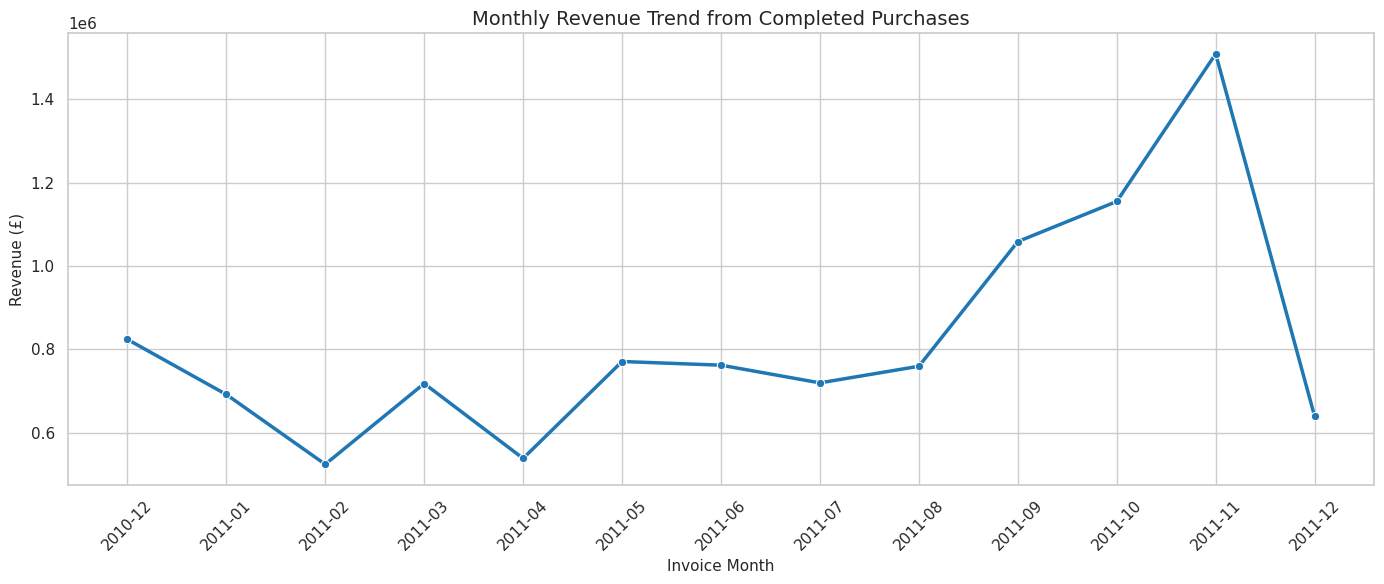

In [28]:
# Monthly revenue
plt.figure(figsize=(14, 6))
sns.lineplot(
    data=monthly_sales,
    x="InvoiceMonth",
    y="Revenue",
    marker="o",
    linewidth=2.5,
    color="#1f77b4"
)
plt.title("Monthly Revenue Trend from Completed Purchases")
plt.xlabel("Invoice Month")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

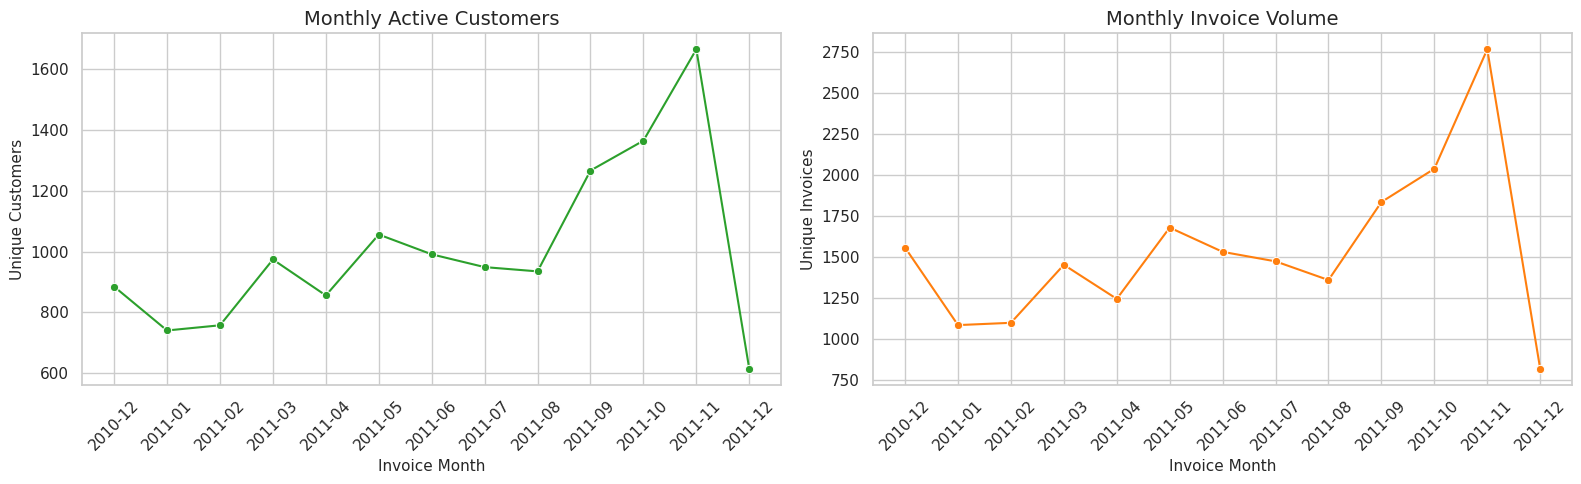

In [29]:
# Monthly unique customers and invoices
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.lineplot(
    data=monthly_sales,
    x="InvoiceMonth",
    y="UniqueCustomers",
    marker="o",
    ax=axes[0],
    color="#2ca02c"
)
axes[0].set_title("Monthly Active Customers")
axes[0].set_xlabel("Invoice Month")
axes[0].set_ylabel("Unique Customers")
axes[0].tick_params(axis="x", rotation=45)

sns.lineplot(
    data=monthly_sales,
    x="InvoiceMonth",
    y="UniqueInvoices",
    marker="o",
    ax=axes[1],
    color="#ff7f0e"
)
axes[1].set_title("Monthly Invoice Volume")
axes[1].set_xlabel("Invoice Month")
axes[1].set_ylabel("Unique Invoices")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

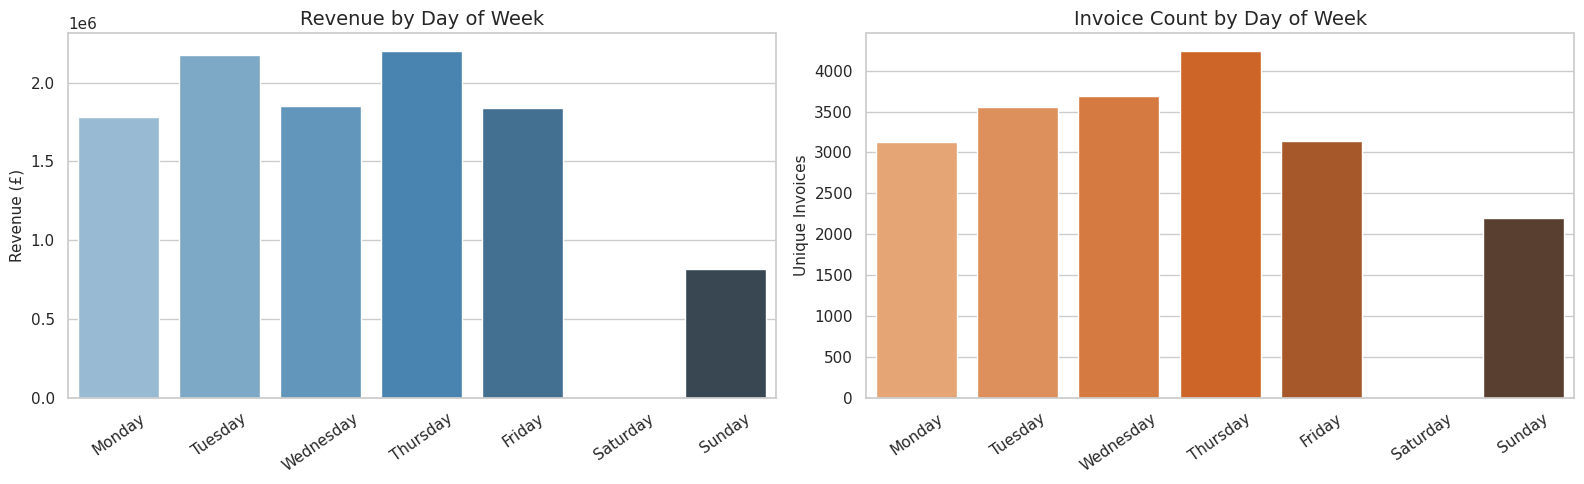

In [30]:
# Sales by day of week
day_order = [
    "Monday", "Tuesday", "Wednesday", "Thursday",
    "Friday", "Saturday", "Sunday"
]

daily_sales = (
    df_completed_eda
    .groupby("DayOfWeek", as_index=False)
    .agg(
        Revenue=("LineRevenue", "sum"),
        UniqueInvoices=("InvoiceNo", "nunique")
    )
)

daily_sales["DayOfWeek"] = pd.Categorical(
    daily_sales["DayOfWeek"],
    categories=day_order,
    ordered=True
)

daily_sales = daily_sales.sort_values("DayOfWeek")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(
    data=daily_sales,
    x="DayOfWeek",
    y="Revenue",
    ax=axes[0],
    palette="Blues_d"
)
axes[0].set_title("Revenue by Day of Week")
axes[0].set_xlabel("")
axes[0].set_ylabel("Revenue (£)")
axes[0].tick_params(axis="x", rotation=35)

sns.barplot(
    data=daily_sales,
    x="DayOfWeek",
    y="UniqueInvoices",
    ax=axes[1],
    palette="Oranges_d"
)
axes[1].set_title("Invoice Count by Day of Week")
axes[1].set_xlabel("")
axes[1].set_ylabel("Unique Invoices")
axes[1].tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()

14. Country level EDA

In [31]:


country_summary = (
    df_completed_eda
    .groupby("Country", as_index=False)
    .agg(
        Revenue=("LineRevenue", "sum"),
        UniqueCustomers=("CustomerID", "nunique"),
        UniqueInvoices=("InvoiceNo", "nunique"),
        LineItems=("InvoiceNo", "size")
    )
    .sort_values("Revenue", ascending=False)
)

country_summary["Revenue Share (%)"] = (
    country_summary["Revenue"] / country_summary["Revenue"].sum() * 100
).round(2)

display(country_summary.head(15))

,Country,Revenue,UniqueCustomers,UniqueInvoices,LineItems,Revenue Share (%)
36,United Kingdom,9025222.084,3920,18019,485123,84.61
24,Netherlands,285446.340,9,94,2359,2.68
10,EIRE,283453.960,3,288,7890,2.66
14,Germany,228867.140,94,457,9040,2.15
13,France,209715.110,87,392,8407,1.97
0,Australia,138521.310,9,57,1182,1.30
31,Spain,61577.110,30,90,2484,0.58
33,Switzerland,57089.900,21,54,1966,0.54
3,Belgium,41196.340,25,98,2031,0.39
32,Sweden,38378.330,8,36,451,0.36


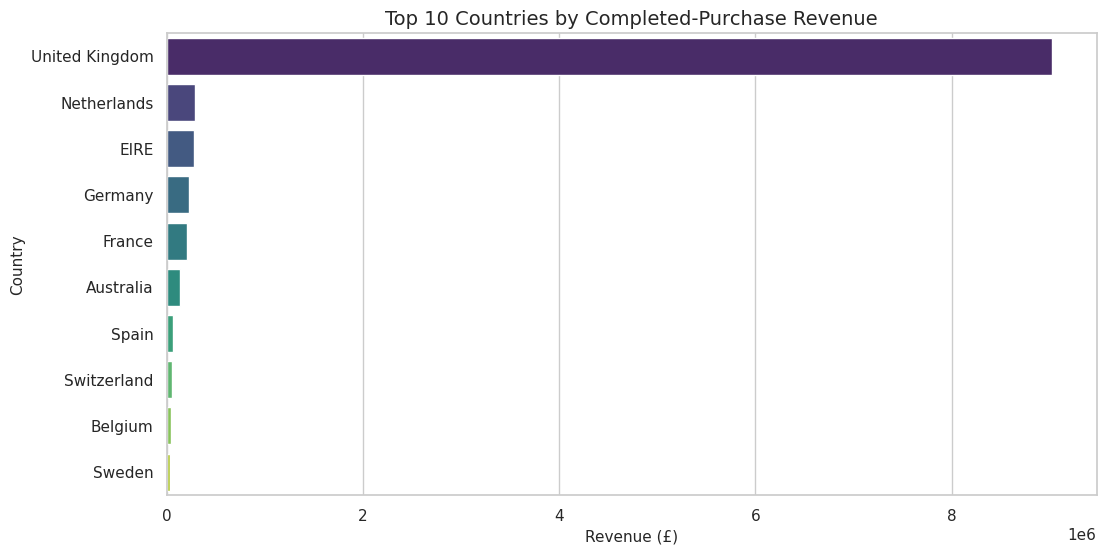

In [32]:
# Top 10 countries by revenue
top_n_countries = 10
top_countries = country_summary.head(top_n_countries)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_countries,
    y="Country",
    x="Revenue",
    palette="viridis"
)
plt.title(f"Top {top_n_countries} Countries by Completed-Purchase Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Country")
plt.show()

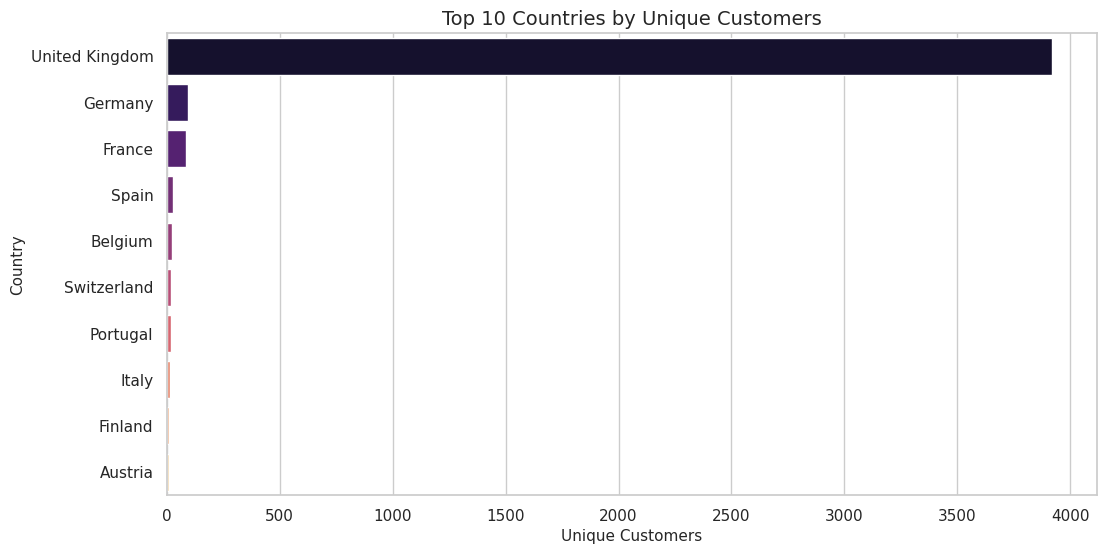

In [33]:
# Top 10 countries by unique customers
top_customer_countries = country_summary.nlargest(10, "UniqueCustomers")

plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_customer_countries,
    y="Country",
    x="UniqueCustomers",
    palette="magma"
)
plt.title("Top 10 Countries by Unique Customers")
plt.xlabel("Unique Customers")
plt.ylabel("Country")
plt.show()

### Country-Level Interpretation

Country is useful for describing where sales and customers are concentrated. However, country should not automatically be included as a numerical feature in distance-based clustering because one-hot encoding can create high-dimensional sparse features and may cause geographical differences to dominate behavioural segmentation.

15. Product-Level EDA

In [34]:


product_summary = (
    df_completed_eda
    .groupby(["StockCode", "Description"], dropna=False, as_index=False)
    .agg(
        QuantitySold=("Quantity", "sum"),
        Revenue=("LineRevenue", "sum"),
        UniqueInvoices=("InvoiceNo", "nunique"),
        UniqueCustomers=("CustomerID", "nunique")
    )
)

top_products_revenue = product_summary.nlargest(15, "Revenue")
top_products_quantity = product_summary.nlargest(15, "QuantitySold")

print("Top products by revenue:")
display(top_products_revenue)

print("Top products by quantity sold:")
display(top_products_quantity)

Top products by revenue:


,StockCode,Description,QuantitySold,Revenue,UniqueInvoices,UniqueCustomers
4150,DOT,DOTCOM POSTAGE,706,206248.77,706,1
1262,22423,REGENCY CAKESTAND 3 TIER,13879,174484.74,1988,881
2590,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,168469.60,1,1
3773,85123A,WHITE HANGING HEART T-LIGHT HOLDER,37599,104340.29,2189,856
2669,47566,PARTY BUNTING,18295,99504.33,1685,708
3761,85099B,JUMBO BAG RED RETROSPOT,48474,94340.05,2089,635
2045,23166,MEDIUM CERAMIC TOP STORAGE JAR,78033,81700.92,247,138
4151,M,Manual,7224,78110.27,289,197
4153,POST,POSTAGE,3150,78101.88,1126,331
1951,23084,RABBIT NIGHT LIGHT,30788,66964.99,994,450


Top products by quantity sold:


,StockCode,Description,QuantitySold,Revenue,UniqueInvoices,UniqueCustomers
2590,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,168469.60,1,1
2045,23166,MEDIUM CERAMIC TOP STORAGE JAR,78033,81700.92,247,138
2769,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,55047,13841.85,535,307
3761,85099B,JUMBO BAG RED RETROSPOT,48474,94340.05,2089,635
3773,85123A,WHITE HANGING HEART T-LIGHT HOLDER,37599,104340.29,2189,856
1051,22197,POPCORN HOLDER,36761,34298.87,803,295
2875,84879,ASSORTED COLOUR BIRD ORNAMENT,36461,59094.93,1455,678
370,21212,PACK OF 72 RETROSPOT CAKE CASES,36419,21259.10,1320,635
1951,23084,RABBIT NIGHT LIGHT,30788,66964.99,994,450
1327,22492,MINI PAINT SET VINTAGE,26633,16937.82,380,213


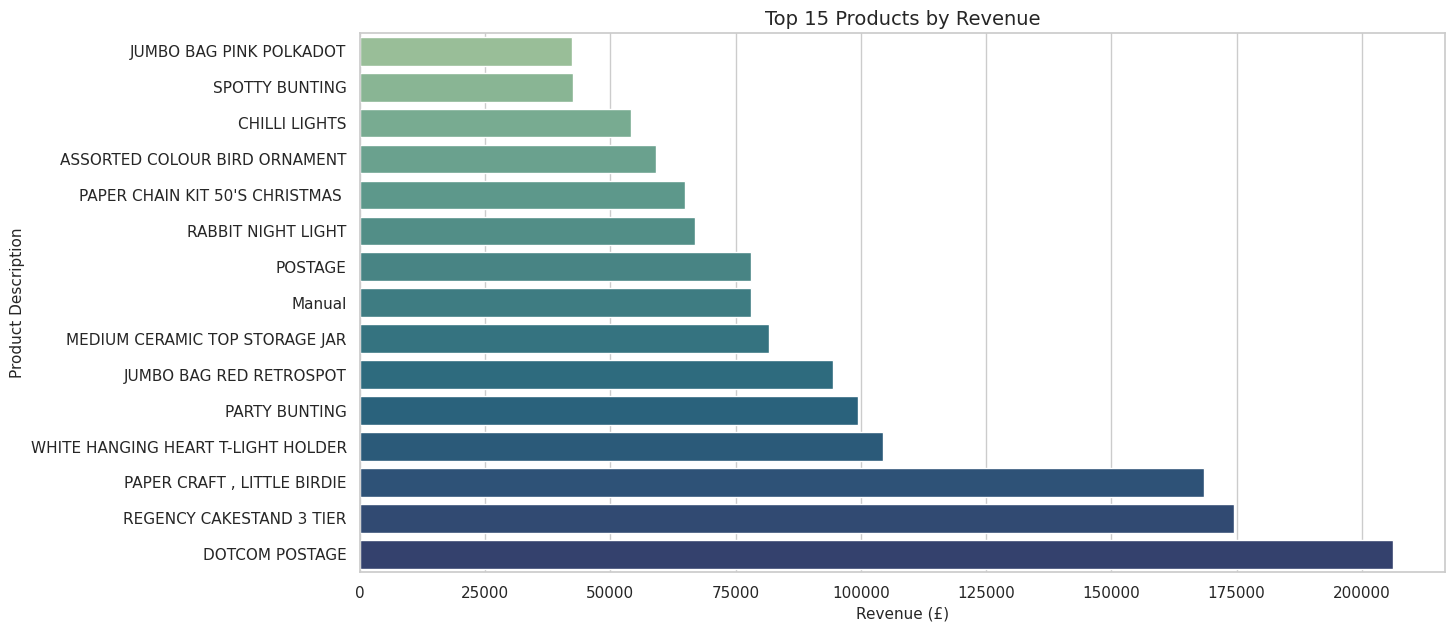

In [35]:
# Top products by revenue
plt.figure(figsize=(14, 7))
sns.barplot(
    data=top_products_revenue.sort_values("Revenue"),
    x="Revenue",
    y="Description",
    palette="crest"
)
plt.title("Top 15 Products by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Product Description")
plt.show()

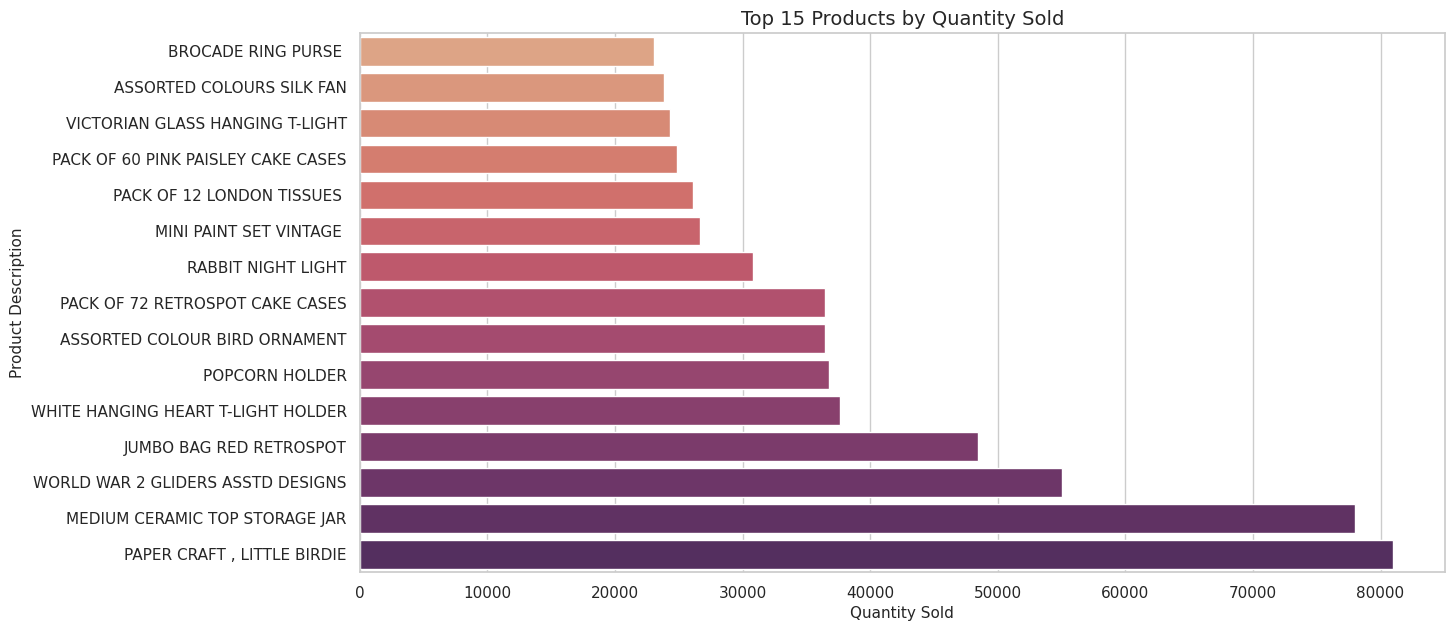

In [36]:
# Top products by quantity sold
plt.figure(figsize=(14, 7))
sns.barplot(
    data=top_products_quantity.sort_values("QuantitySold"),
    x="QuantitySold",
    y="Description",
    palette="flare"
)
plt.title("Top 15 Products by Quantity Sold")
plt.xlabel("Quantity Sold")
plt.ylabel("Product Description")
plt.show()

In [37]:
# Long-tail product concentration
product_revenue_sorted = product_summary.sort_values("Revenue", ascending=False).reset_index(drop=True)
product_revenue_sorted["Cumulative Revenue Share (%)"] = (
    product_revenue_sorted["Revenue"].cumsum()
    / product_revenue_sorted["Revenue"].sum() * 100
)

top_10_product_share = product_revenue_sorted.head(10)["Revenue"].sum() / product_revenue_sorted["Revenue"].sum() * 100
top_50_product_share = product_revenue_sorted.head(50)["Revenue"].sum() / product_revenue_sorted["Revenue"].sum() * 100
top_100_product_share = product_revenue_sorted.head(100)["Revenue"].sum() / product_revenue_sorted["Revenue"].sum() * 100

print(f"Revenue share from top 10 products: {top_10_product_share:.2f}%")
print(f"Revenue share from top 50 products: {top_50_product_share:.2f}%")
print(f"Revenue share from top 100 products: {top_100_product_share:.2f}%")

Revenue share from top 10 products: 10.80%
Revenue share from top 50 products: 23.46%
Revenue share from top 100 products: 33.79%


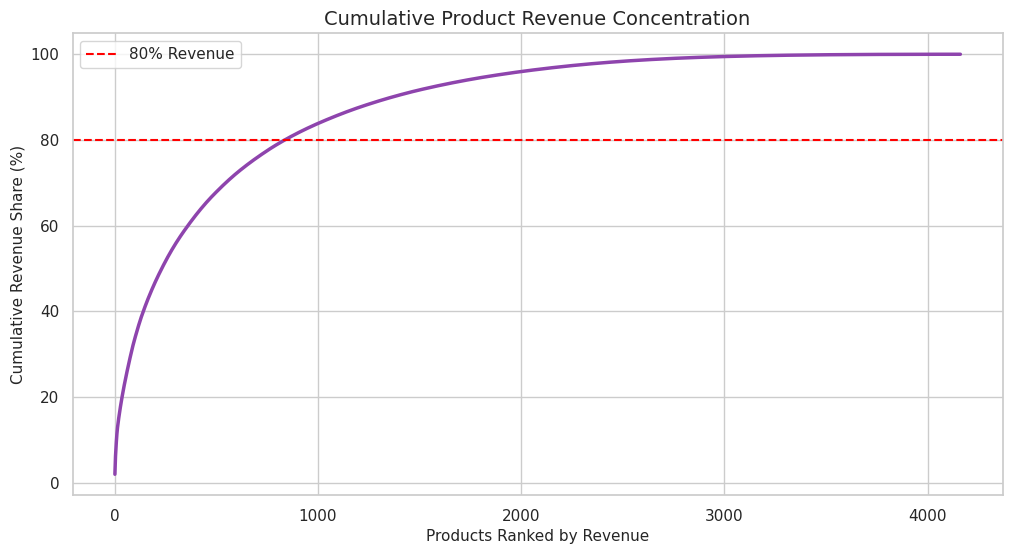

In [38]:
# Product revenue concentration curve
plt.figure(figsize=(12, 6))
plt.plot(
    range(1, len(product_revenue_sorted) + 1),
    product_revenue_sorted["Cumulative Revenue Share (%)"],
    color="#8e44ad",
    linewidth=2.5
)

plt.axhline(80, color="red", linestyle="--", label="80% Revenue")
plt.title("Cumulative Product Revenue Concentration")
plt.xlabel("Products Ranked by Revenue")
plt.ylabel("Cumulative Revenue Share (%)")
plt.legend()
plt.show()

### Product-Level Interpretation

Retail product demand is expected to be highly skewed: a small number of products can contribute a large share of revenue or transactions, while many products occur rarely.

This pattern matters for the association-rule stage. Very rare products may generate unreliable or overly specific rules, so the association-rule member should consider minimum-support thresholds and may need to remove non-product codes or extremely rare items before Apriori analysis.

16. Quantity, Price, and Revenue Distributions

In [39]:

distribution_data = df_completed_eda[
    ["Quantity", "UnitPrice", "LineRevenue"]
].replace([np.inf, -np.inf], np.nan).dropna()

print("Skewness:")
display(distribution_data.skew().to_frame(name="Skewness"))

print("Selected percentiles:")
display(
    distribution_data.describe(
        percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
    ).T
)

Skewness:


,Skewness
Quantity,471.727716
UnitPrice,206.087555
LineRevenue,506.706012


Selected percentiles:


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
Quantity,530104.0,10.542037,155.524124,1.000,1.00,1.00,1.00,3.00,10.00,30.00,100.00,80995.00
UnitPrice,530104.0,3.907625,35.915681,0.001,0.29,0.42,1.25,2.08,4.13,9.95,16.98,13541.33
LineRevenue,530104.0,20.121871,270.356743,0.001,0.55,1.25,3.75,9.90,17.70,59.70,183.60,168469.60


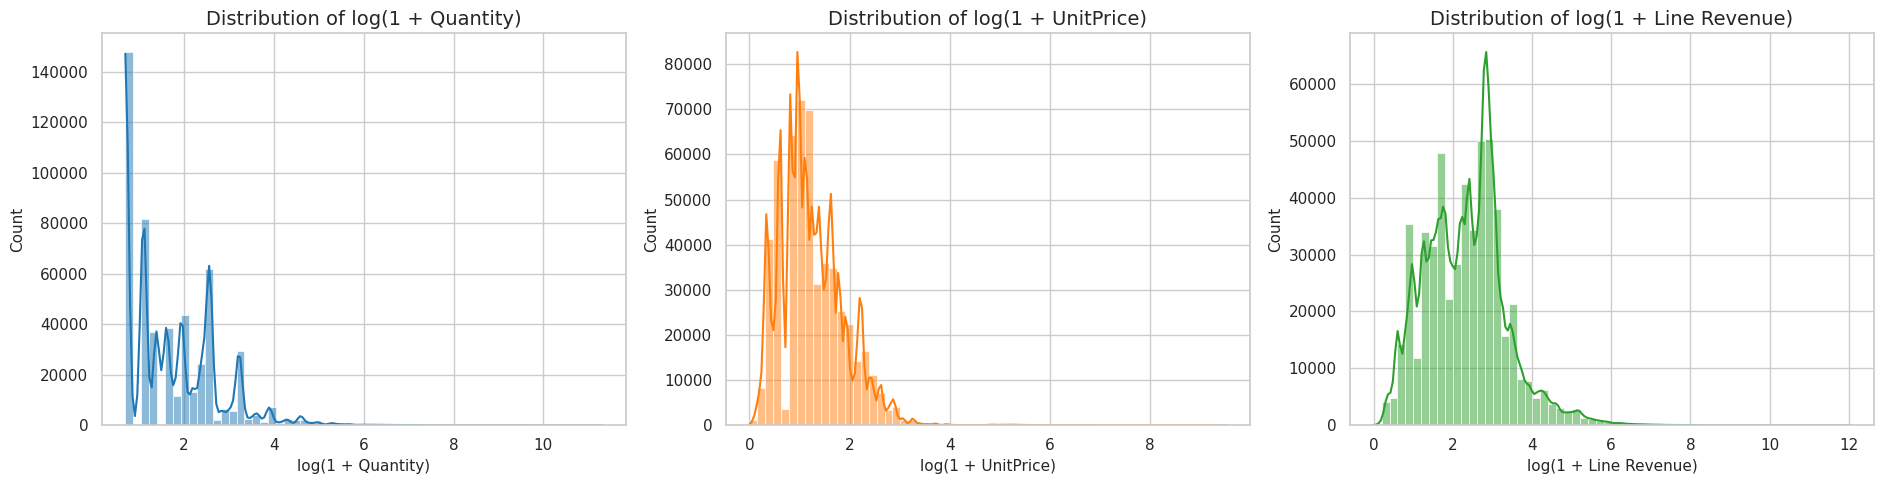

In [40]:
# Histograms using log-scale / log1p views to make heavy-tailed distributions visible
fig, axes = plt.subplots(1, 3, figsize=(19, 5))

sns.histplot(
    np.log1p(df_completed_eda["Quantity"]),
    bins=60,
    kde=True,
    ax=axes[0],
    color="#1f77b4"
)
axes[0].set_title("Distribution of log(1 + Quantity)")
axes[0].set_xlabel("log(1 + Quantity)")

sns.histplot(
    np.log1p(df_completed_eda["UnitPrice"]),
    bins=60,
    kde=True,
    ax=axes[1],
    color="#ff7f0e"
)
axes[1].set_title("Distribution of log(1 + UnitPrice)")
axes[1].set_xlabel("log(1 + UnitPrice)")

sns.histplot(
    np.log1p(df_completed_eda["LineRevenue"]),
    bins=60,
    kde=True,
    ax=axes[2],
    color="#2ca02c"
)
axes[2].set_title("Distribution of log(1 + Line Revenue)")
axes[2].set_xlabel("log(1 + Line Revenue)")

plt.tight_layout()
plt.show()

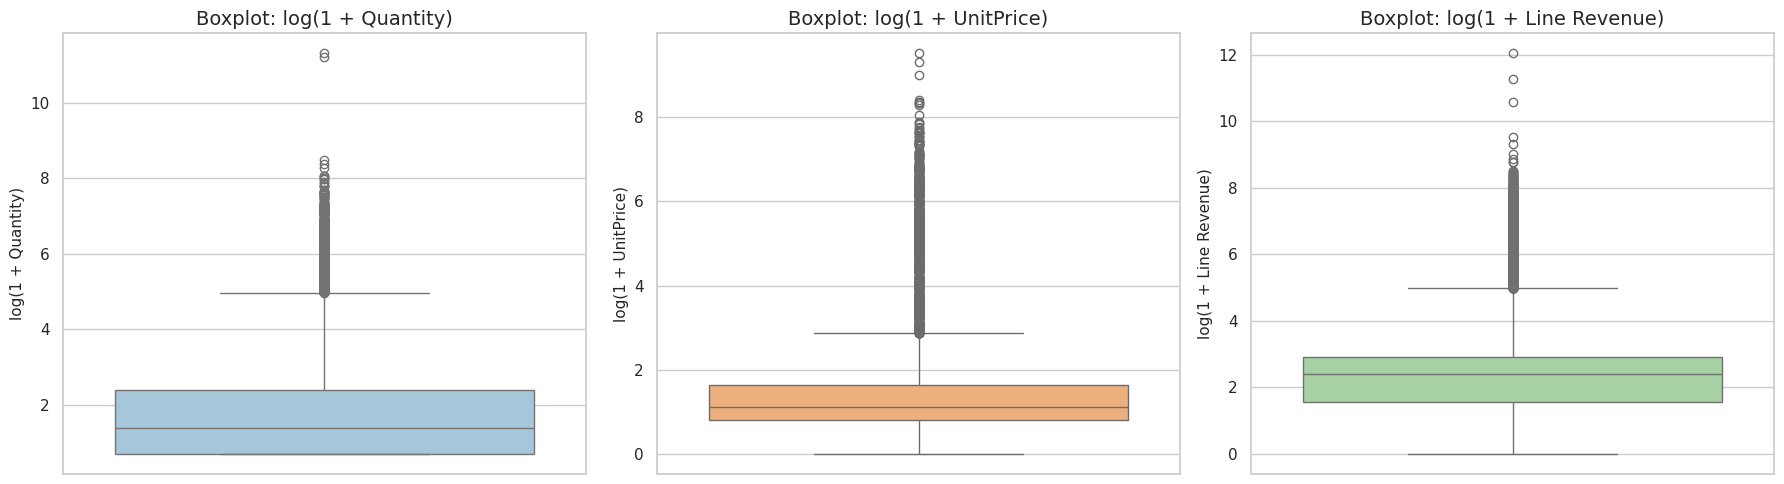

In [41]:
# Boxplots on log-transformed values
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(y=np.log1p(df_completed_eda["Quantity"]), ax=axes[0], color="#9ecae1")
axes[0].set_title("Boxplot: log(1 + Quantity)")
axes[0].set_ylabel("log(1 + Quantity)")

sns.boxplot(y=np.log1p(df_completed_eda["UnitPrice"]), ax=axes[1], color="#fdae6b")
axes[1].set_title("Boxplot: log(1 + UnitPrice)")
axes[1].set_ylabel("log(1 + UnitPrice)")

sns.boxplot(y=np.log1p(df_completed_eda["LineRevenue"]), ax=axes[2], color="#a1d99b")
axes[2].set_title("Boxplot: log(1 + Line Revenue)")
axes[2].set_ylabel("log(1 + Line Revenue)")

plt.tight_layout()
plt.show()

Quantity, UnitPrice, and LineRevenue are expected to be strongly right-skewed because most retail purchases are small while a minority of transactions are unusually large.

This is important for later customer-level features such as Frequency, Monetary value, average basket value, and return-related measures. The preprocessing member should evaluate log transformations for highly skewed non-negative features and use RobustScaler because it is less influenced by extreme values than standard scaling.

17. Outlier Screening

In [42]:


def iqr_outlier_summary(series):
    series = series.dropna()
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outlier_mask = (series < lower_bound) | (series > upper_bound)

    return pd.Series({
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Potential Outliers": outlier_mask.sum(),
        "Potential Outlier %": round(outlier_mask.mean() * 100, 2)
    })

outlier_summary = pd.DataFrame({
    "Quantity": iqr_outlier_summary(df_completed_eda["Quantity"]),
    "UnitPrice": iqr_outlier_summary(df_completed_eda["UnitPrice"]),
    "LineRevenue": iqr_outlier_summary(df_completed_eda["LineRevenue"])
}).T

display(outlier_summary)

,Q1,Q3,IQR,Lower Bound,Upper Bound,Potential Outliers,Potential Outlier %
Quantity,1.00,10.00,9.00,-12.500,23.500,56363.0,10.63
UnitPrice,1.25,4.13,2.88,-3.070,8.450,37999.0,7.17
LineRevenue,3.75,17.70,13.95,-17.175,38.625,42651.0,8.05


In [43]:
# Inspect highest value completed purchase lines
high_value_lines = df_completed_eda.nlargest(
    20, "LineRevenue"
)[
    [
        "InvoiceNo", "StockCode", "Description",
        "Quantity", "UnitPrice", "LineRevenue",
        "CustomerID", "Country", "InvoiceDate"
    ]
]

display(high_value_lines)

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,LineRevenue,CustomerID,Country,InvoiceDate
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,168469.60,16446.0,United Kingdom,2011-12-09 09:15:00
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04,77183.60,12346.0,United Kingdom,2011-01-18 10:01:00
222680,556444,22502,PICNIC BASKET WICKER 60 PIECES,60,649.50,38970.00,15098.0,United Kingdom,2011-06-10 15:28:00
15017,537632,AMAZONFEE,AMAZON FEE,1,13541.33,13541.33,NaN,United Kingdom,2010-12-07 15:08:00
299982,A563185,B,Adjust bad debt,1,11062.06,11062.06,NaN,United Kingdom,2011-08-12 14:50:00
173382,551697,POST,POSTAGE,1,8142.75,8142.75,16029.0,United Kingdom,2011-05-03 13:46:00
348325,567423,23243,SET OF TEA COFFEE SUGAR TINS PANTRY,1412,5.06,7144.72,17450.0,United Kingdom,2011-09-20 11:05:00
52711,540815,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,6539.40,15749.0,United Kingdom,2011-01-11 12:55:00
160546,550461,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,6539.40,15749.0,United Kingdom,2011-04-18 13:20:00
421601,573003,23084,RABBIT NIGHT LIGHT,2400,2.08,4992.00,14646.0,Netherlands,2011-10-27 12:11:00


In [44]:
# Inspect highest-value completed purchase lines
high_value_lines = df_completed_eda.nlargest(
    20, "LineRevenue"
)[
    [
        "InvoiceNo", "StockCode", "Description",
        "Quantity", "UnitPrice", "LineRevenue",
        "CustomerID", "Country", "InvoiceDate"
    ]
]

display(high_value_lines)

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,LineRevenue,CustomerID,Country,InvoiceDate
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,168469.60,16446.0,United Kingdom,2011-12-09 09:15:00
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04,77183.60,12346.0,United Kingdom,2011-01-18 10:01:00
222680,556444,22502,PICNIC BASKET WICKER 60 PIECES,60,649.50,38970.00,15098.0,United Kingdom,2011-06-10 15:28:00
15017,537632,AMAZONFEE,AMAZON FEE,1,13541.33,13541.33,NaN,United Kingdom,2010-12-07 15:08:00
299982,A563185,B,Adjust bad debt,1,11062.06,11062.06,NaN,United Kingdom,2011-08-12 14:50:00
173382,551697,POST,POSTAGE,1,8142.75,8142.75,16029.0,United Kingdom,2011-05-03 13:46:00
348325,567423,23243,SET OF TEA COFFEE SUGAR TINS PANTRY,1412,5.06,7144.72,17450.0,United Kingdom,2011-09-20 11:05:00
52711,540815,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,6539.40,15749.0,United Kingdom,2011-01-11 12:55:00
160546,550461,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,6539.40,15749.0,United Kingdom,2011-04-18 13:20:00
421601,573003,23084,RABBIT NIGHT LIGHT,2400,2.08,4992.00,14646.0,Netherlands,2011-10-27 12:11:00


IQR-based outlier flags are screening indicators, not proof that a transaction is invalid. A high-value customer or large order may be commercially important, especially in a wholesale retailer.

Therefore:
- Remove only records confirmed to be errors or invalid transactions.
- Retain valid high-value purchases because they contain meaningful customer value information.
- Reduce their modelling influence later using log transformation and RobustScaler.
- Consider reporting highly unusual customers separately during final segmentation interpretation.

18. Customer Purchase Behaviour EDA

In [46]:
customer_eda = (
    df_completed_eda
    .dropna(subset=["CustomerID"])
    .groupby("CustomerID", as_index=False)
    .agg(
        FirstPurchaseDate=("InvoiceDate", "min"),
        LastPurchaseDate=("InvoiceDate", "max"),
        InvoiceFrequency=("InvoiceNo", "nunique"),
        TotalRevenue=("LineRevenue", "sum"),
        TotalQuantity=("Quantity", "sum"),
        UniqueProducts=("StockCode", "nunique"),
        UniqueDescriptions=("Description", "nunique"),
        CountriesPurchasedFrom=("Country", "nunique")
    )
)

customer_eda["AnalysisDate"] = df_completed_eda["InvoiceDate"].max() + pd.Timedelta(days=1)
customer_eda["RecencyDays"] = (
    customer_eda["AnalysisDate"] - customer_eda["LastPurchaseDate"]
).dt.days

customer_eda["AvgRevenuePerInvoice"] = (
    customer_eda["TotalRevenue"] / customer_eda["InvoiceFrequency"]
)

customer_eda["AvgQuantityPerInvoice"] = (
    customer_eda["TotalQuantity"] / customer_eda["InvoiceFrequency"]
)

print("Customer-level EDA dataset shape:", customer_eda.shape)
display(customer_eda.head())

Customer-level EDA dataset shape: (4338, 13)


,CustomerID,FirstPurchaseDate,LastPurchaseDate,InvoiceFrequency,TotalRevenue,TotalQuantity,UniqueProducts,UniqueDescriptions,CountriesPurchasedFrom,AnalysisDate,RecencyDays,AvgRevenuePerInvoice,AvgQuantityPerInvoice
0,12346.0,2011-01-18 10:01:00,2011-01-18 10:01:00,1,77183.60,74215,1,1,1,2011-12-10 12:50:00,326,77183.600000,74215.000000
1,12347.0,2010-12-07 14:57:00,2011-12-07 15:52:00,7,4310.00,2458,103,103,1,2011-12-10 12:50:00,2,615.714286,351.142857
2,12348.0,2010-12-16 19:09:00,2011-09-25 13:13:00,4,1797.24,2341,22,22,1,2011-12-10 12:50:00,75,449.310000,585.250000
3,12349.0,2011-11-21 09:51:00,2011-11-21 09:51:00,1,1757.55,631,73,73,1,2011-12-10 12:50:00,19,1757.550000,631.000000
4,12350.0,2011-02-02 16:01:00,2011-02-02 16:01:00,1,334.40,197,17,17,1,2011-12-10 12:50:00,310,334.400000,197.000000


In [47]:
# Customer-level descriptive statistics
customer_eda_summary = customer_eda[
    [
        "RecencyDays",
        "InvoiceFrequency",
        "TotalRevenue",
        "TotalQuantity",
        "UniqueProducts",
        "AvgRevenuePerInvoice",
        "AvgQuantityPerInvoice"
    ]
].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
).T

customer_eda_summary["Skewness"] = customer_eda[
    [
        "RecencyDays",
        "InvoiceFrequency",
        "TotalRevenue",
        "TotalQuantity",
        "UniqueProducts",
        "AvgRevenuePerInvoice",
        "AvgQuantityPerInvoice"
    ]
].skew()

display(customer_eda_summary)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,Skewness
RecencyDays,4338.0,92.536422,100.014169,1.00,1.000,3.0000,18.000,51.000,142.00000,312.000000,369.0000,374.00,1.246048
InvoiceFrequency,4338.0,4.272015,7.697998,1.00,1.000,1.0000,1.000,2.000,5.00000,13.000000,30.0000,209.00,12.067031
TotalRevenue,4338.0,2054.266460,8989.230441,3.75,52.200,112.3095,307.415,674.485,1661.74000,5841.843000,19880.9957,280206.02,19.324953
TotalQuantity,4338.0,1191.289073,5046.081546,1.00,12.000,46.0000,160.000,379.000,992.75000,3570.900000,11046.5800,196915.00,20.359611
UniqueProducts,4338.0,61.501153,85.366768,1.00,1.000,4.0000,16.000,35.000,77.00000,205.000000,354.0000,1787.00,6.919445
AvgRevenuePerInvoice,4338.0,419.166289,1796.537944,3.45,43.311,90.5820,178.625,293.900,430.11375,937.211833,2031.1612,84236.25,41.688126
AvgQuantityPerInvoice,4338.0,253.478280,1312.905974,1.00,11.000,35.0000,93.000,161.750,272.00000,600.000000,1377.7200,74215.00,47.991247


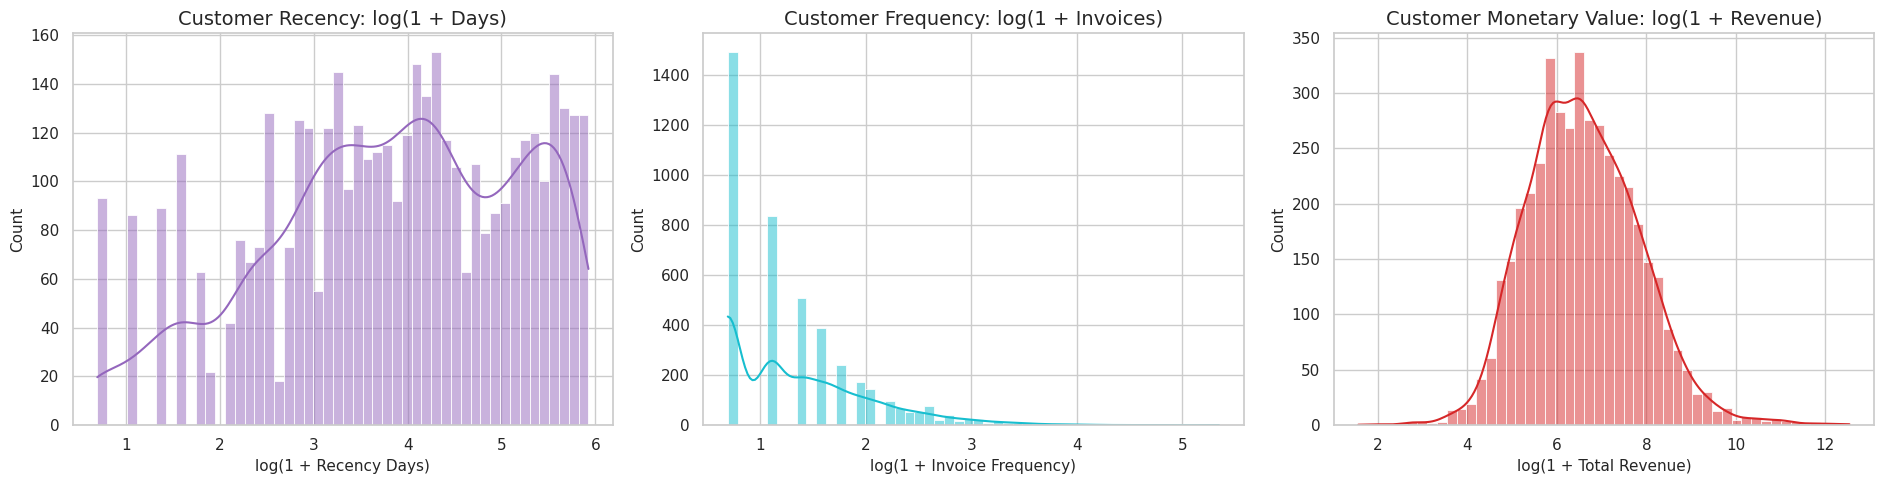

In [48]:
# RFM-style customer distributions
fig, axes = plt.subplots(1, 3, figsize=(19, 5))

sns.histplot(
    np.log1p(customer_eda["RecencyDays"]),
    bins=50,
    kde=True,
    ax=axes[0],
    color="#9467bd"
)
axes[0].set_title("Customer Recency: log(1 + Days)")
axes[0].set_xlabel("log(1 + Recency Days)")

sns.histplot(
    np.log1p(customer_eda["InvoiceFrequency"]),
    bins=50,
    kde=True,
    ax=axes[1],
    color="#17becf"
)
axes[1].set_title("Customer Frequency: log(1 + Invoices)")
axes[1].set_xlabel("log(1 + Invoice Frequency)")

sns.histplot(
    np.log1p(customer_eda["TotalRevenue"]),
    bins=50,
    kde=True,
    ax=axes[2],
    color="#d62728"
)
axes[2].set_title("Customer Monetary Value: log(1 + Revenue)")
axes[2].set_xlabel("log(1 + Total Revenue)")

plt.tight_layout()
plt.show()

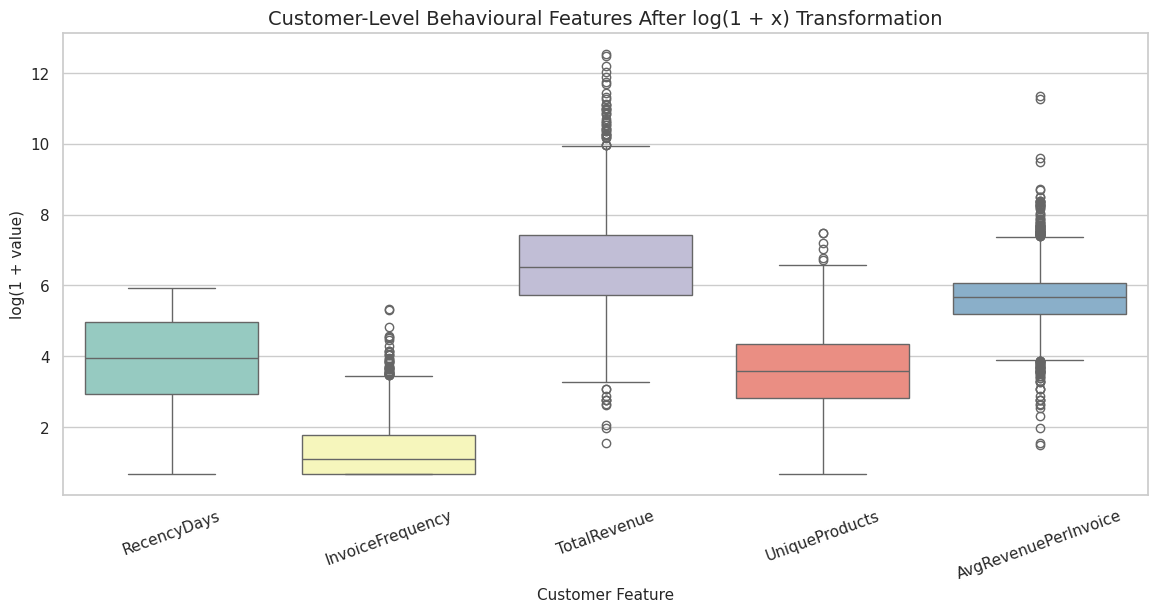

In [49]:
# Customer-level boxplots on log-transformed behavioural measures
customer_features_for_plot = [
    "RecencyDays",
    "InvoiceFrequency",
    "TotalRevenue",
    "UniqueProducts",
    "AvgRevenuePerInvoice"
]

customer_log_plot = customer_eda[customer_features_for_plot].copy()

for column in customer_log_plot.columns:
    customer_log_plot[column] = np.log1p(customer_log_plot[column])

plt.figure(figsize=(14, 6))
sns.boxplot(data=customer_log_plot, palette="Set3")
plt.title("Customer-Level Behavioural Features After log(1 + x) Transformation")
plt.xlabel("Customer Feature")
plt.ylabel("log(1 + value)")
plt.xticks(rotation=20)
plt.show()

The customer-level EDA confirms whether RFM and behavioural features are highly skewed before modelling. RFM segmentation is a transparent baseline for this dataset, while additional features such as item diversity, return rate, and average basket value can create a richer behavioural representation.





19. Customer Feature Correlation

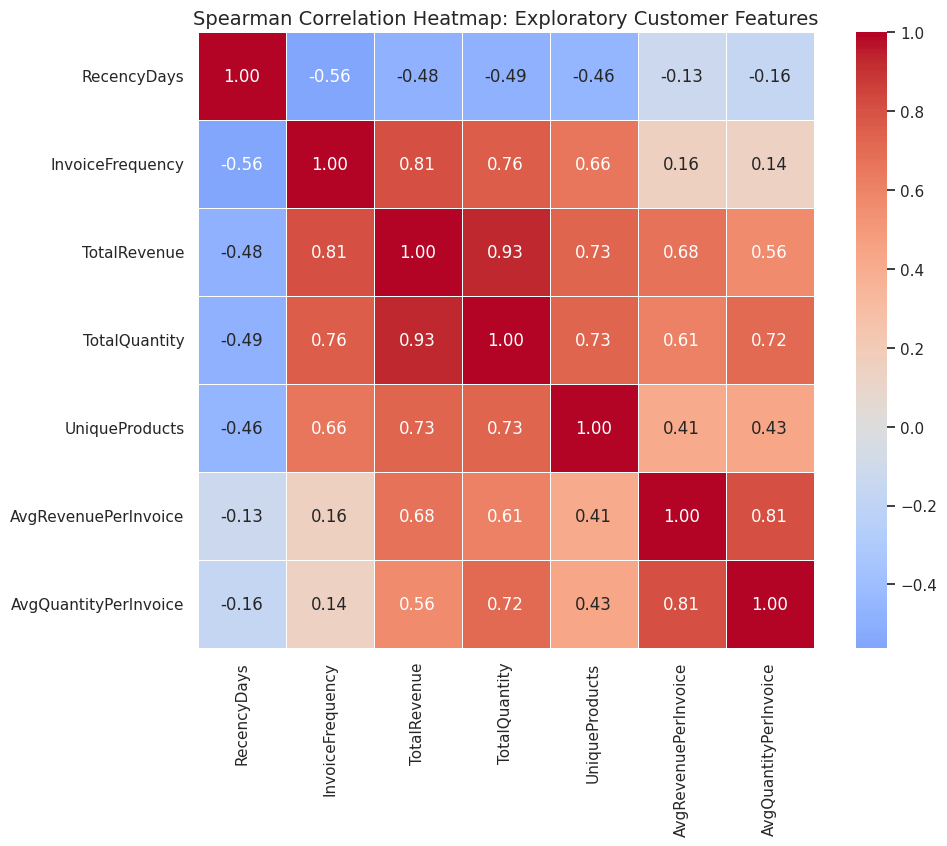

In [50]:


customer_numeric_features = [
    "RecencyDays",
    "InvoiceFrequency",
    "TotalRevenue",
    "TotalQuantity",
    "UniqueProducts",
    "AvgRevenuePerInvoice",
    "AvgQuantityPerInvoice"
]

correlation_matrix = customer_eda[customer_numeric_features].corr(method="spearman")

plt.figure(figsize=(11, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)
plt.title("Spearman Correlation Heatmap: Exploratory Customer Features")
plt.show()

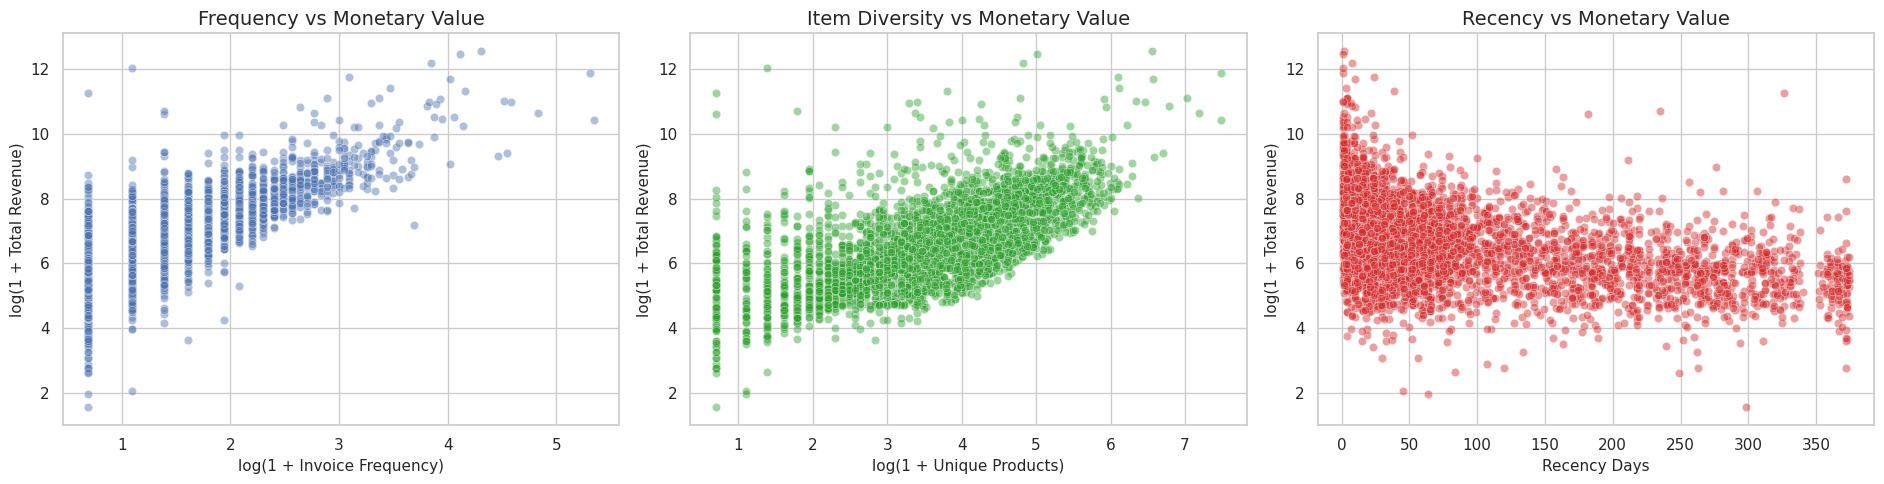

In [51]:
# Selected scatterplots in log space
plot_customer = customer_eda.copy()

for col in ["InvoiceFrequency", "TotalRevenue", "UniqueProducts", "AvgRevenuePerInvoice"]:
    plot_customer[f"log_{col}"] = np.log1p(plot_customer[col])

fig, axes = plt.subplots(1, 3, figsize=(19, 5))

sns.scatterplot(
    data=plot_customer,
    x="log_InvoiceFrequency",
    y="log_TotalRevenue",
    alpha=0.45,
    ax=axes[0]
)
axes[0].set_title("Frequency vs Monetary Value")
axes[0].set_xlabel("log(1 + Invoice Frequency)")
axes[0].set_ylabel("log(1 + Total Revenue)")

sns.scatterplot(
    data=plot_customer,
    x="log_UniqueProducts",
    y="log_TotalRevenue",
    alpha=0.45,
    ax=axes[1],
    color="#2ca02c"
)
axes[1].set_title("Item Diversity vs Monetary Value")
axes[1].set_xlabel("log(1 + Unique Products)")
axes[1].set_ylabel("log(1 + Total Revenue)")

sns.scatterplot(
    data=plot_customer,
    x="RecencyDays",
    y="log_TotalRevenue",
    alpha=0.45,
    ax=axes[2],
    color="#d62728"
)
axes[2].set_title("Recency vs Monetary Value")
axes[2].set_xlabel("Recency Days")
axes[2].set_ylabel("log(1 + Total Revenue)")

plt.tight_layout()
plt.show()

The correlation heatmap is used to identify relationships and possible redundancy among future customer-level features. For example, TotalRevenue and InvoiceFrequency may be positively related because frequent customers often spend more.

Highly correlated features should not automatically be removed because they may represent different business concepts. However, the preprocessing member should avoid creating many near-duplicate features that overweight the same behavioural signal in distance-based clustering.

20. Invoice / Basket EDA for Association Rules

In [52]:



invoice_eda = (
    df_completed_eda
    .dropna(subset=["CustomerID"])
    .groupby("InvoiceNo", as_index=False)
    .agg(
        CustomerID=("CustomerID", "first"),
        InvoiceDate=("InvoiceDate", "min"),
        BasketRevenue=("LineRevenue", "sum"),
        BasketQuantity=("Quantity", "sum"),
        UniqueProducts=("StockCode", "nunique"),
        UniqueProductDescriptions=("Description", "nunique")
    )
)

display(invoice_eda.head())

invoice_eda_summary = invoice_eda[
    [
        "BasketRevenue",
        "BasketQuantity",
        "UniqueProducts",
        "UniqueProductDescriptions"
    ]
].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
).T

invoice_eda_summary["Skewness"] = invoice_eda[
    [
        "BasketRevenue",
        "BasketQuantity",
        "UniqueProducts",
        "UniqueProductDescriptions"
    ]
].skew()

display(invoice_eda_summary)

,InvoiceNo,CustomerID,InvoiceDate,BasketRevenue,BasketQuantity,UniqueProducts,UniqueProductDescriptions
0,536365,17850.0,2010-12-01 08:26:00,139.12,40,7,7
1,536366,17850.0,2010-12-01 08:28:00,22.20,12,2,2
2,536367,13047.0,2010-12-01 08:34:00,278.73,83,12,12
3,536368,13047.0,2010-12-01 08:34:00,70.05,15,4,4
4,536369,13047.0,2010-12-01 08:35:00,17.85,3,1,1


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,Skewness
BasketRevenue,18532.0,480.865956,1678.195579,0.38,8.5,38.2,158.0375,303.04,471.84,1236.5925,3849.0214,168469.6,62.139131
BasketQuantity,18532.0,278.858839,972.718727,1.00,1.0,12.0,74.0000,155.00,291.00,778.0000,2270.6900,80995.0,56.499729
UniqueProducts,18532.0,20.928178,23.816197,1.00,1.0,1.0,6.0000,15.00,27.00,62.0000,104.0000,541.0,5.356753
UniqueProductDescriptions,18532.0,20.922620,23.809117,1.00,1.0,1.0,6.0000,15.00,27.00,62.0000,104.0000,541.0,5.358919


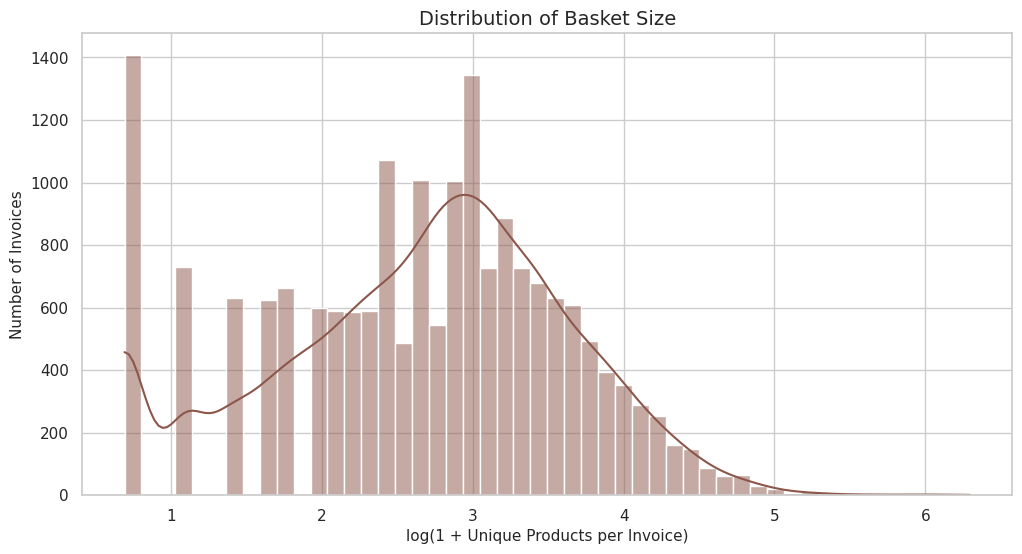

In [53]:
# Basket size distribution
plt.figure(figsize=(12, 6))
sns.histplot(
    np.log1p(invoice_eda["UniqueProducts"]),
    bins=50,
    kde=True,
    color="#8c564b"
)
plt.title("Distribution of Basket Size")
plt.xlabel("log(1 + Unique Products per Invoice)")
plt.ylabel("Number of Invoices")
plt.show()

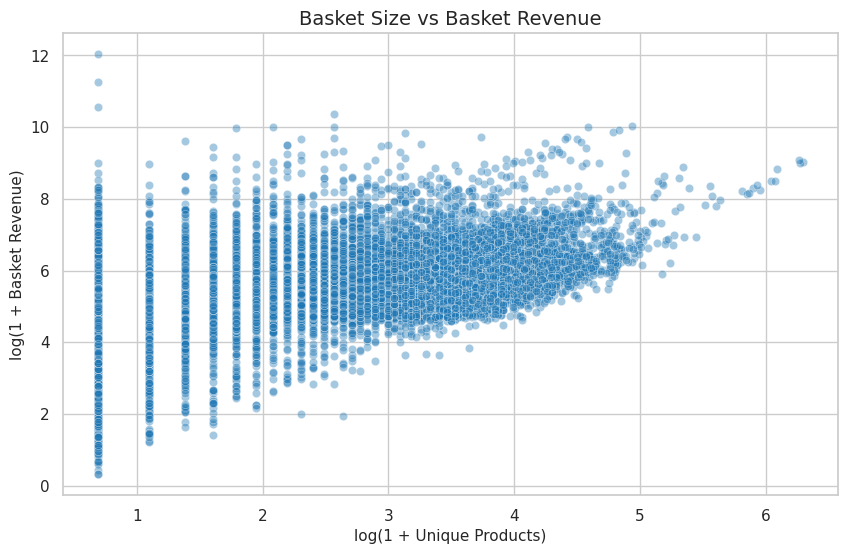

In [54]:
# Relationship between basket size and basket revenue
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=invoice_eda,
    x=np.log1p(invoice_eda["UniqueProducts"]),
    y=np.log1p(invoice_eda["BasketRevenue"]),
    alpha=0.4,
    color="#1f77b4"
)
plt.title("Basket Size vs Basket Revenue")
plt.xlabel("log(1 + Unique Products)")
plt.ylabel("log(1 + Basket Revenue)")
plt.show()

### Basket-Level Interpretation

Each completed invoice will later be treated as one transaction for market-basket analysis. Product associations should be calculated using product presence within an invoice, rather than product quantities, because Apriori examines whether products occur together in a basket.

Before Apriori, the association-rule member should:
- Use completed purchase invoices only.
- Remove cancellation invoices and invalid quantity/price records.
- Exclude non-product StockCodes where necessary.
- Use StockCode for computation and Description for readable reporting.
- Consider filtering extremely rare products.
- Run association mining separately within final customer segments.

21. Non-Product StockCode Audit

In [55]:


stockcode_audit = (
    df_completed_eda
    .groupby("StockCode", as_index=False)
    .agg(
        ExampleDescription=("Description", "first"),
        LineItems=("InvoiceNo", "size"),
        UniqueInvoices=("InvoiceNo", "nunique"),
        Revenue=("LineRevenue", "sum"),
        Quantity=("Quantity", "sum")
    )
    .sort_values("Revenue", ascending=False)
)

# Display codes that are not purely numeric.
# This is an investigation list, not an automatic removal list.
stockcode_audit["StockCode_str"] = stockcode_audit["StockCode"].astype(str).str.strip()
stockcode_audit["IsNumericCode"] = stockcode_audit["StockCode_str"].str.fullmatch(r"\d+")

special_stockcodes = stockcode_audit[
    ~stockcode_audit["IsNumericCode"]
].copy()

print("Number of non-numeric StockCodes:", special_stockcodes.shape[0])
display(special_stockcodes.head(30))

Number of non-numeric StockCodes: 1054


,StockCode,ExampleDescription,LineItems,UniqueInvoices,Revenue,Quantity,StockCode_str,IsNumericCode
3911,DOT,DOTCOM POSTAGE,706,706,206248.77,706,DOT,False
3539,85123A,WHITE HANGING HEART T-LIGHT HOLDER,2265,2198,104518.80,37660,85123A,False
3528,85099B,JUMBO BAG RED RETROSPOT,2112,2089,94340.05,48474,85099B,False
3912,M,Manual,321,289,78110.27,7224,M,False
3914,POST,POSTAGE,1126,1126,78101.88,3150,POST,False
3530,85099F,JUMBO BAG STRAWBERRY,824,812,32570.47,17273,85099F,False
3529,85099C,JUMBO BAG BAROQUE BLACK WHITE,946,933,28092.20,13922,85099C,False
2876,15056N,EDWARDIAN PARASOL NATURAL,460,456,22176.49,3954,15056N,False
3205,84029E,RED WOOLLY HOTTIE WHITE HEART.,443,429,22144.98,4765,84029E,False
3453,84997D,PINK 3 PIECE POLKADOT CUTLERY SET,478,473,19736.50,5105,84997D,False


In [56]:
# Search for descriptions that may indicate non-product or operational items
keywords = [
    "POSTAGE", "DISCOUNT", "BANK CHARGES", "MANUAL",
    "ADJUST", "CARRIAGE", "DOTCOM", "AMAZON", "SAMPLES"
]

pattern = "|".join(keywords)

special_description_rows = df_completed_eda[
    df_completed_eda["Description"]
    .astype(str)
    .str.upper()
    .str.contains(pattern, na=False)
].copy()

special_description_summary = (
    special_description_rows
    .groupby(["StockCode", "Description"], as_index=False)
    .agg(
        Rows=("InvoiceNo", "size"),
        UniqueInvoices=("InvoiceNo", "nunique"),
        Revenue=("LineRevenue", "sum")
    )
    .sort_values("Revenue", ascending=False)
)

display(special_description_summary.head(30))

,StockCode,Description,Rows,UniqueInvoices,Revenue
10,DOT,DOTCOM POSTAGE,706,706,206248.770
11,M,Manual,321,289,78110.270
12,POST,POSTAGE,1126,1126,78101.880
6,AMAZONFEE,AMAZON FEE,2,2,13761.090
7,B,Adjust bad debt,1,1,11062.060
9,C2,CARRIAGE,141,141,7051.000
4,23444,Next Day Carriage,79,79,1200.000
3,23099,FRENCH CARRIAGE LANTERN,59,58,925.350
5,85168B,BLACK BAROQUE CARRIAGE CLOCK,35,35,432.790
16,gift_0001_30,Dotcomgiftshop Gift Voucher £30.00,7,7,175.530


Some StockCodes may represent operational charges, postage, discounts, adjustments, or other non-merchandise entries rather than physical products. These entries may be valid financial records but should be reviewed before item-diversity calculation and Apriori market-basket analysis.

The preprocessing and association-rule members should produce and document a final rule for excluding non-product codes. The rule must be based on inspection of StockCode and Description values, not only on arbitrary assumptions.

22. PCA Readiness Note

PCA will be used later only after customer-level features have been cleaned, transformed, and scaled. It can reduce the customer-feature space to two principal components for visualising cluster separation and possible unusual observations.

PCA is not used at the raw invoice-line stage because the clustering unit of analysis is the customer, not an individual invoice line.

23. Automated EDA Insight Log

In [72]:


total_rows = len(df_raw)
missing_customer_pct = df_raw["CustomerID"].isna().mean() * 100
missing_description_pct = df_raw["Description"].isna().mean() * 100
cancellation_pct = df_eda["IsCancellation"].mean() * 100
nonpositive_quantity_pct = (df_raw["Quantity"] <= 0).mean() * 100
nonpositive_price_pct = (df_raw["UnitPrice"] <= 0).mean() * 100
duplicate_pct = df_raw.duplicated().mean() * 100

customer_revenue_skew = customer_eda["TotalRevenue"].skew()
customer_frequency_skew = customer_eda["InvoiceFrequency"].skew()
customer_recency_skew = customer_eda["RecencyDays"].skew()

top_country = country_summary.iloc[0]["Country"]
top_country_share = country_summary.iloc[0]["Revenue Share (%)"]

top_product = top_products_revenue.iloc[0]["Description"]
top_product_revenue = top_products_revenue.iloc[0]["Revenue"]

insight_log = pd.DataFrame({
    "EDA Area": [
        "Dataset granularity",
        "Missing CustomerID",
        "Missing Description",
        "Cancellations",
        "Invalid quantity",
        "Invalid UnitPrice",
        "Exact duplicates",
        "Customer monetary skewness",
        "Customer frequency skewness",
        "Customer recency skewness",
        "Geographical concentration",
        "Product concentration"
    ],
    "Observed Evidence": [
        "Raw data are invoice-line records, while the segmentation unit is the customer.",
        f"{missing_customer_pct:.2f}% of rows have a missing CustomerID.",
        f"{missing_description_pct:.2f}% of rows have a missing Description.",
        f"{cancellation_pct:.2f}% of rows are cancellation invoices (InvoiceNo starts with C).",
        f"{nonpositive_quantity_pct:.2f}% of rows have Quantity <= 0.",
        f"{nonpositive_price_pct:.2f}% of rows have UnitPrice <= 0.",
        f"{duplicate_pct:.4f}% of rows are exact duplicates.",
        f"Customer total revenue skewness = {customer_revenue_skew:.2f}.",
        f"Customer invoice frequency skewness = {customer_frequency_skew:.2f}.",
        f"Customer recency skewness = {customer_recency_skew:.2f}.",
        f"{top_country} is the highest-revenue country with {top_country_share:.2f}% of completed-purchase revenue.",
        f"Top revenue product: {top_product} with revenue of £{top_product_revenue:,.2f}."
    ],
    "Implication for Next Phase": [
        "Aggregate valid transactions to customer level before clustering.",
        "Remove rows missing CustomerID from customer-level clustering data; do not impute identifiers.",
        "Inspect before association analysis; descriptions are needed for interpretable product rules.",
        "Separate cancellations/returns from completed purchases; consider return behaviour for a feature.",
        "Exclude non-positive quantities from completed-purchase RFM and market-basket data.",
        "Exclude non-positive prices from revenue-based modelling and basket analysis.",
        "Inspect exact duplicates and remove only confirmed duplicates.",
        "Use log1p transformation and RobustScaler for monetary-related customer features.",
        "Use log1p transformation and RobustScaler for frequency-related customer features.",
        "Review recency distribution; scaling remains necessary before distance-based clustering.",
        "Treat Country mainly as a profiling variable unless inclusion is clearly justified.",
        "Use minimum-support thresholds and rare-item filtering for association rules."
    ]
})

display(insight_log)

,EDA Area,Observed Evidence,Implication for Next Phase
0,Dataset granularity,"Raw data are invoice-line records, while the s...",Aggregate valid transactions to customer level...
1,Missing CustomerID,24.93% of rows have a missing CustomerID.,Remove rows missing CustomerID from customer-l...
2,Missing Description,0.27% of rows have a missing Description.,Inspect before association analysis; descripti...
3,Cancellations,1.71% of rows are cancellation invoices (Invoi...,Separate cancellations/returns from completed ...
4,Invalid quantity,1.96% of rows have Quantity <= 0.,Exclude non-positive quantities from completed...
5,Invalid UnitPrice,0.46% of rows have UnitPrice <= 0.,Exclude non-positive prices from revenue-based...
6,Exact duplicates,0.9721% of rows are exact duplicates.,Inspect exact duplicates and remove only confi...
7,Customer monetary skewness,Customer total revenue skewness = 19.32.,Use log1p transformation and RobustScaler for ...
8,Customer frequency skewness,Customer invoice frequency skewness = 12.07.,Use log1p transformation and RobustScaler for ...
9,Customer recency skewness,Customer recency skewness = 1.25.,Review recency distribution; scaling remains n...


In [73]:
# Save the insight log to Drive for use in the final report
OUTPUT_DIR = "/content/drive/MyDrive/ML Project/project_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

insight_log_path = os.path.join(OUTPUT_DIR, "eda_insight_log.csv")
insight_log.to_csv(insight_log_path, index=False)

print("EDA insight log saved to:")
print(insight_log_path)

EDA insight log saved to:
/content/drive/MyDrive/ML Project/project_outputs/eda_insight_log.csv


Handover to the Preprocessing Member

## 24. Handover: EDA Findings to Preprocessing and Feature Engineering

Based on the exploratory analysis, the preprocessing and feature-engineering stage should implement the following decisions.

| EDA finding | Required preprocessing / feature-engineering action | Reason |
|---|---|---|
| Raw data are invoice-line records | Aggregate valid transaction data to customer level | Customer segmentation requires one row per customer |
| CustomerID contains missing values | Remove rows with missing CustomerID from segmentation data | Customer-level RFM and behavioural features cannot be calculated without a customer identifier |
| Cancellation invoices exist | Create a cancellation flag; exclude cancellation invoices from completed-purchase RFM and Apriori datasets | Cancellations are reversals/returns rather than completed purchase demand |
| Negative or zero Quantity / UnitPrice values exist | Retain only Quantity > 0 and UnitPrice > 0 for completed-purchase dataset | Valid revenue and product baskets require positive purchases |
| Exact duplicates may exist | Inspect and remove only confirmed exact duplicate records | Avoid removing valid repeated purchases |
| Quantity, revenue, frequency, and basket features are highly skewed | Apply `log1p` transformation to appropriate non-negative customer features | Reduce right-skewness and extreme-value influence |
| Wholesale / high-value customers may exist | Use RobustScaler after transformations | Robust scaling is less sensitive to extreme values |
| Product codes include possible operational entries | Inspect and exclude non-product codes from item diversity and Apriori data | Product association rules should represent merchandise relationships |
| Country is concentrated and categorical | Use primarily for profiling and recommendation context | Avoid allowing location to dominate behavioural distance calculations |
| Product demand is long-tailed | Filter extremely rare products when generating Apriori rules | Reduce weak, unhelpful, and overly specific rules |